selesai -> /home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision/article-reports
['r310_table_latent_summary.csv', 'r310_table_subtype_probe.csv', 'fig_r310_umap_main.png', 'fig_r310_umap_supp_ciciot2023.png', 'fig_r310_umap_supp_edge_iiotset.png']


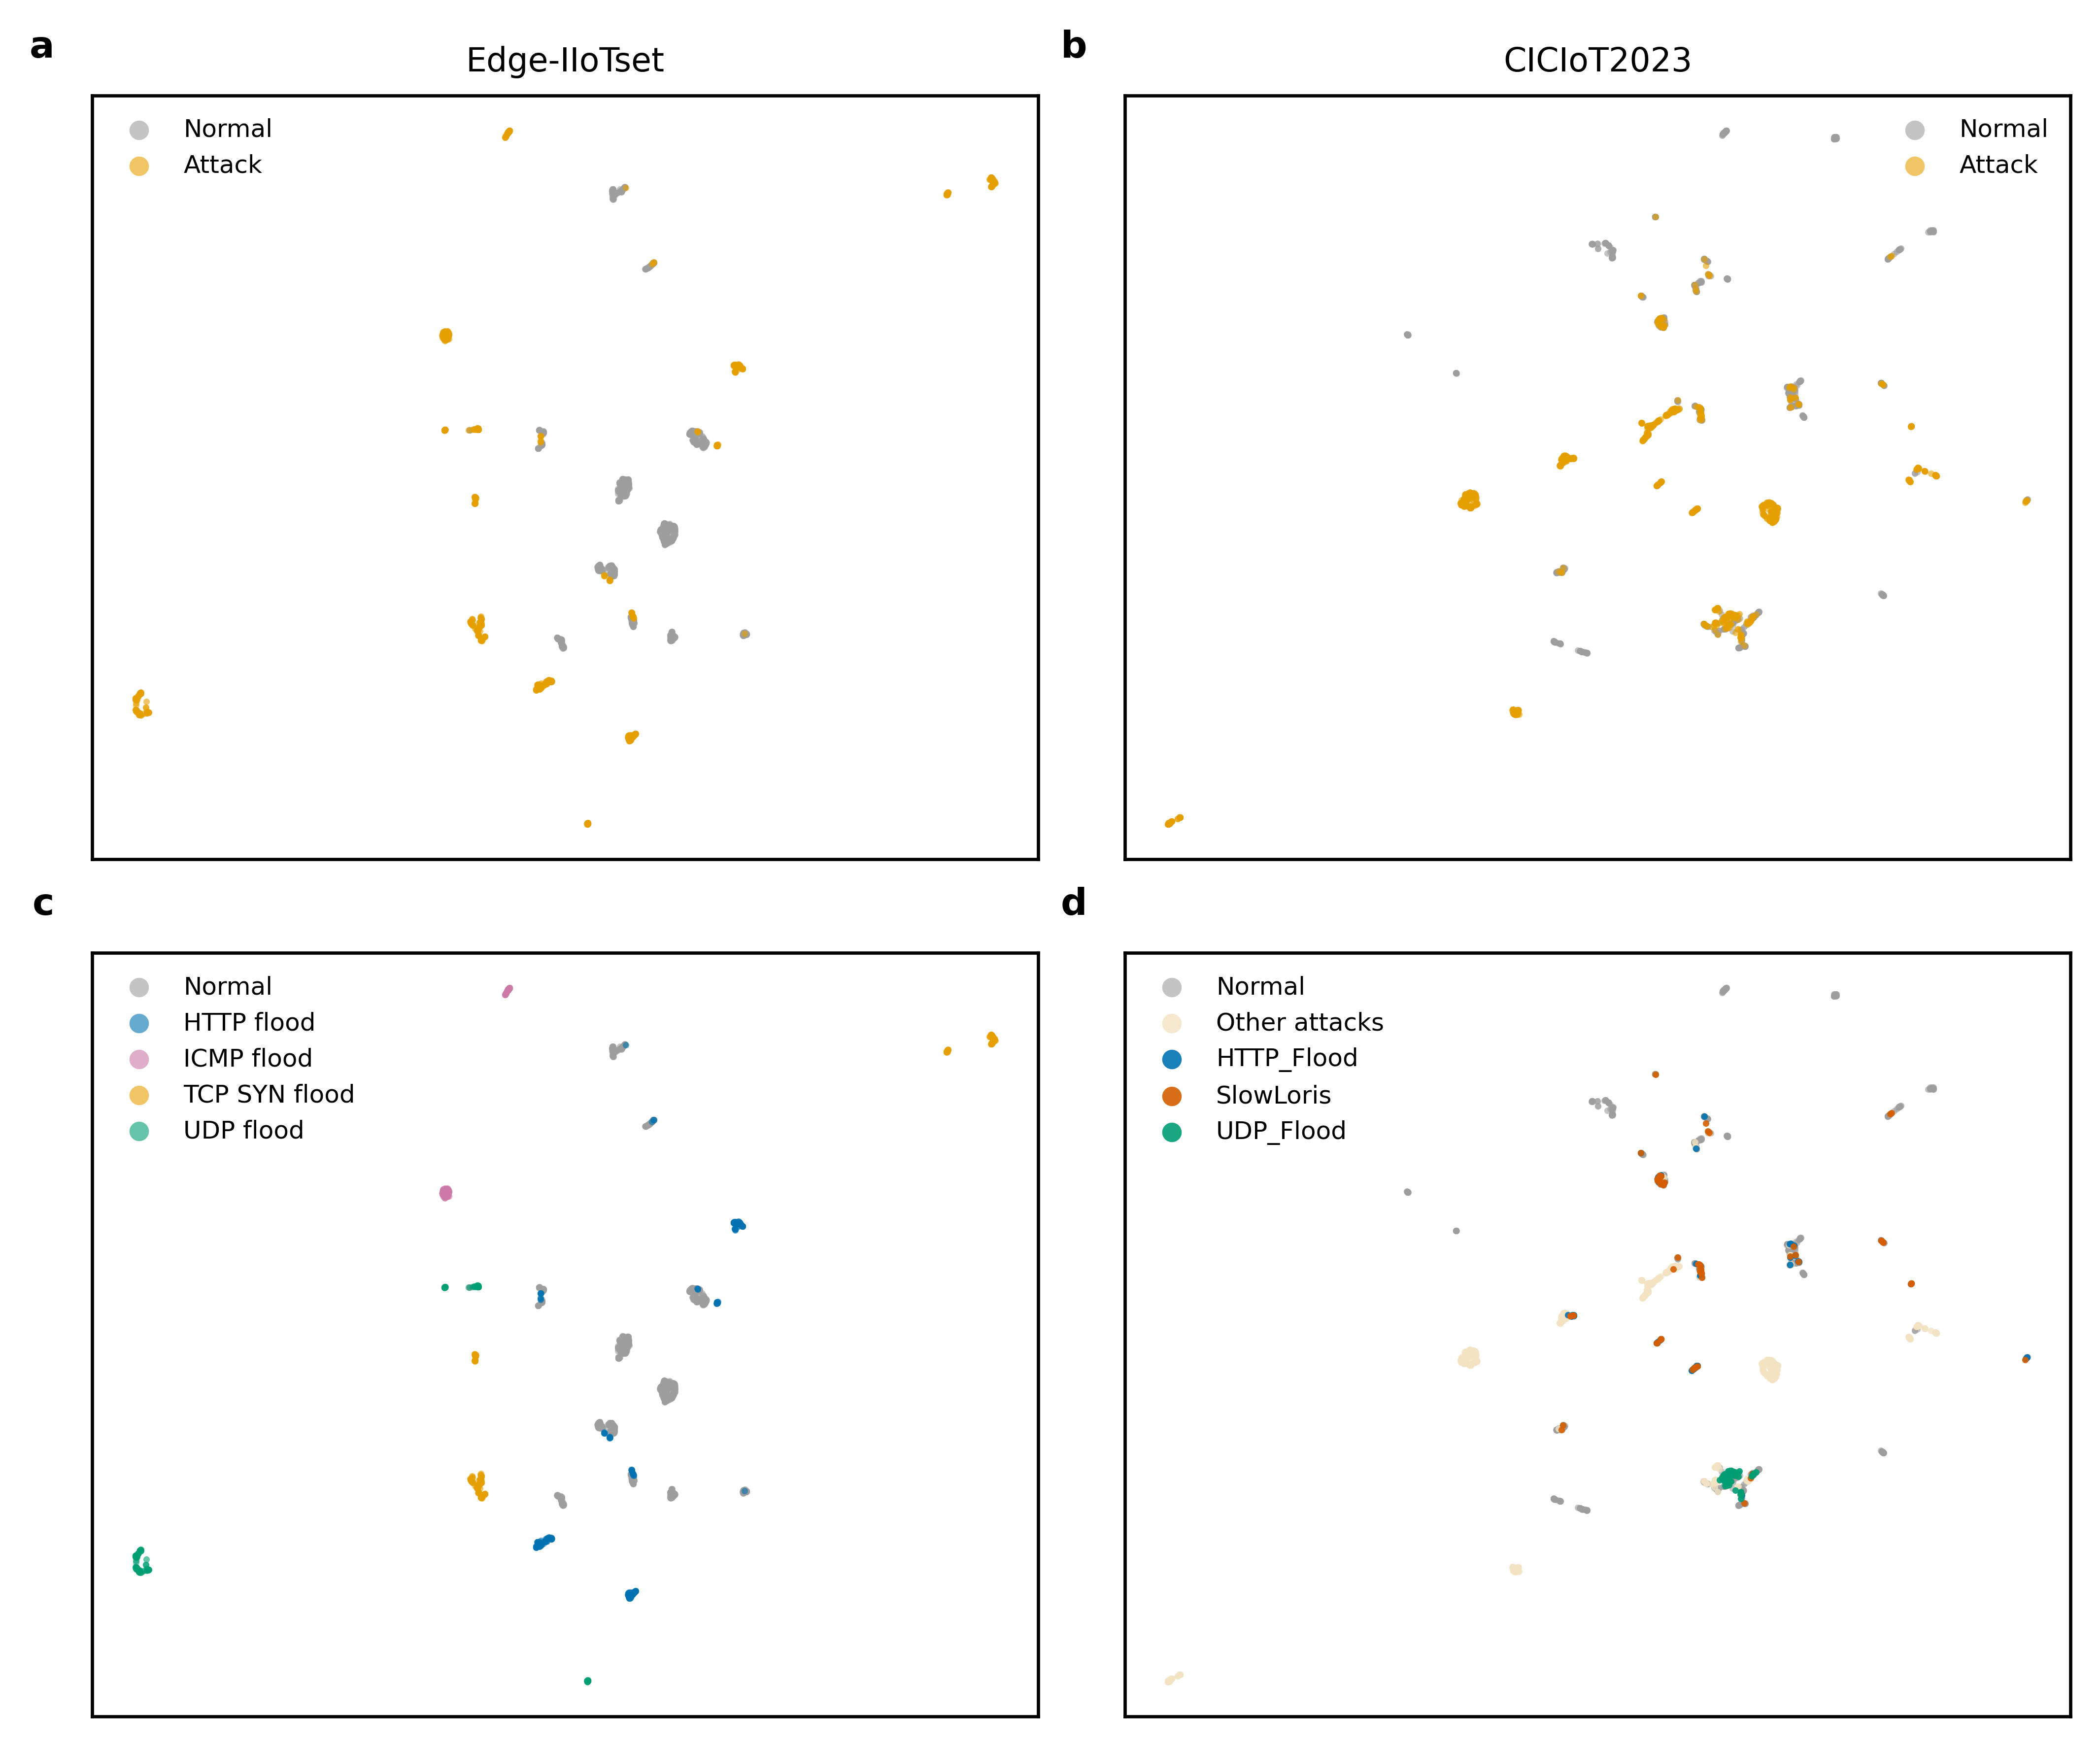

In [4]:
# ======== START: R3.10 GAMBAR + TABEL -> article-reports ========
import os, numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import wilcoxon
from IPython.display import Image, display
BASE = Path("/home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision")
REP = BASE / "article-reports"; REP.mkdir(exist_ok=True)
LAT = BASE / "06-posthoc/latent"
os.chdir(BASE)

# --- gambar: PNG saja, 600 dpi, langsung ke article-reports
src = (open("fig_r310_umap.py").read()
       .replace("s=S, c=c,", "s=S, color=c,")
       .replace('OUT = ROOT / "figs"; OUT.mkdir(exist_ok=True)', f'OUT = Path("{REP}")')
       .replace('for ext in ("pdf", "png"):', 'for ext in ("png",):')
       .replace("dpi=300", "dpi=600"))
exec(compile(src, "fig_r310_umap.py", "exec"))

# --- tabel ringkasan
q = lambda s: f"{s.median():.4f} [{s.quantile(.25):.4f}, {s.quantile(.75):.4f}]"
rows, subs = [], []
for ds in ["edge_iiotset", "ciciot2023"]:
    f = pd.read_csv(LAT / ds / "per_fold.csv")
    n = pd.read_csv(LAT / ds / "neurons_per_fold.csv")
    n["L"] = (n.p_holm < .05) & (n.cliffs_delta.abs() >= .474)
    k = n.groupby("unit").L.sum()
    for c in ["auc_latent", "auc_dense", "auc_input", "sil_latent", "sil_dense",
              "sil_input", "pct_attack_identical", "n_unique_normal"]:
        rows.append(dict(dataset=ds, metric=c, median_IQR=q(f[c]),
                         mean=round(f[c].mean(), 4), sd=round(f[c].std(), 4)))
    rows.append(dict(dataset=ds, metric="neurons_large_sig_per_fold",
                     median_IQR=q(k), mean=round(k.mean(), 2), sd=round(k.std(), 2)))
    for a, b in [("auc_latent", "auc_dense"), ("sil_latent", "sil_dense")]:
        rows.append(dict(dataset=ds, metric=f"wilcoxon_{a}_vs_{b}",
                         median_IQR=q(f[a] - f[b]), mean=np.nan,
                         sd=round(wilcoxon(f[a], f[b]).pvalue, 4)))
    s = pd.read_csv(LAT / ds / "subtype_per_fold.csv")
    g = s.groupby("subtype")[["n", "auc_latent", "auc_dense", "auc_input",
                              "pct_identical"]].median().round(3)
    subs.append(g.reset_index().assign(dataset=ds))
pd.DataFrame(rows).to_csv(REP / "r310_table_latent_summary.csv", index=False)
pd.concat(subs)[["dataset", "subtype", "n", "auc_latent", "auc_dense", "auc_input",
                 "pct_identical"]].to_csv(REP / "r310_table_subtype_probe.csv", index=False)

print(sorted(p.name for p in REP.glob("r310_*")) + sorted(p.name for p in REP.glob("fig_r310_*")))
display(Image(filename=str(REP / "fig_r310_umap_main.png"), width=900))
# ======== END: R3.10 GAMBAR + TABEL -> article-reports ========

persentil: ['p90', 'p95', 'p96', 'p97', 'p98', 'p99', 'p99.5', 'p99.9', 'p99.99', 'max']


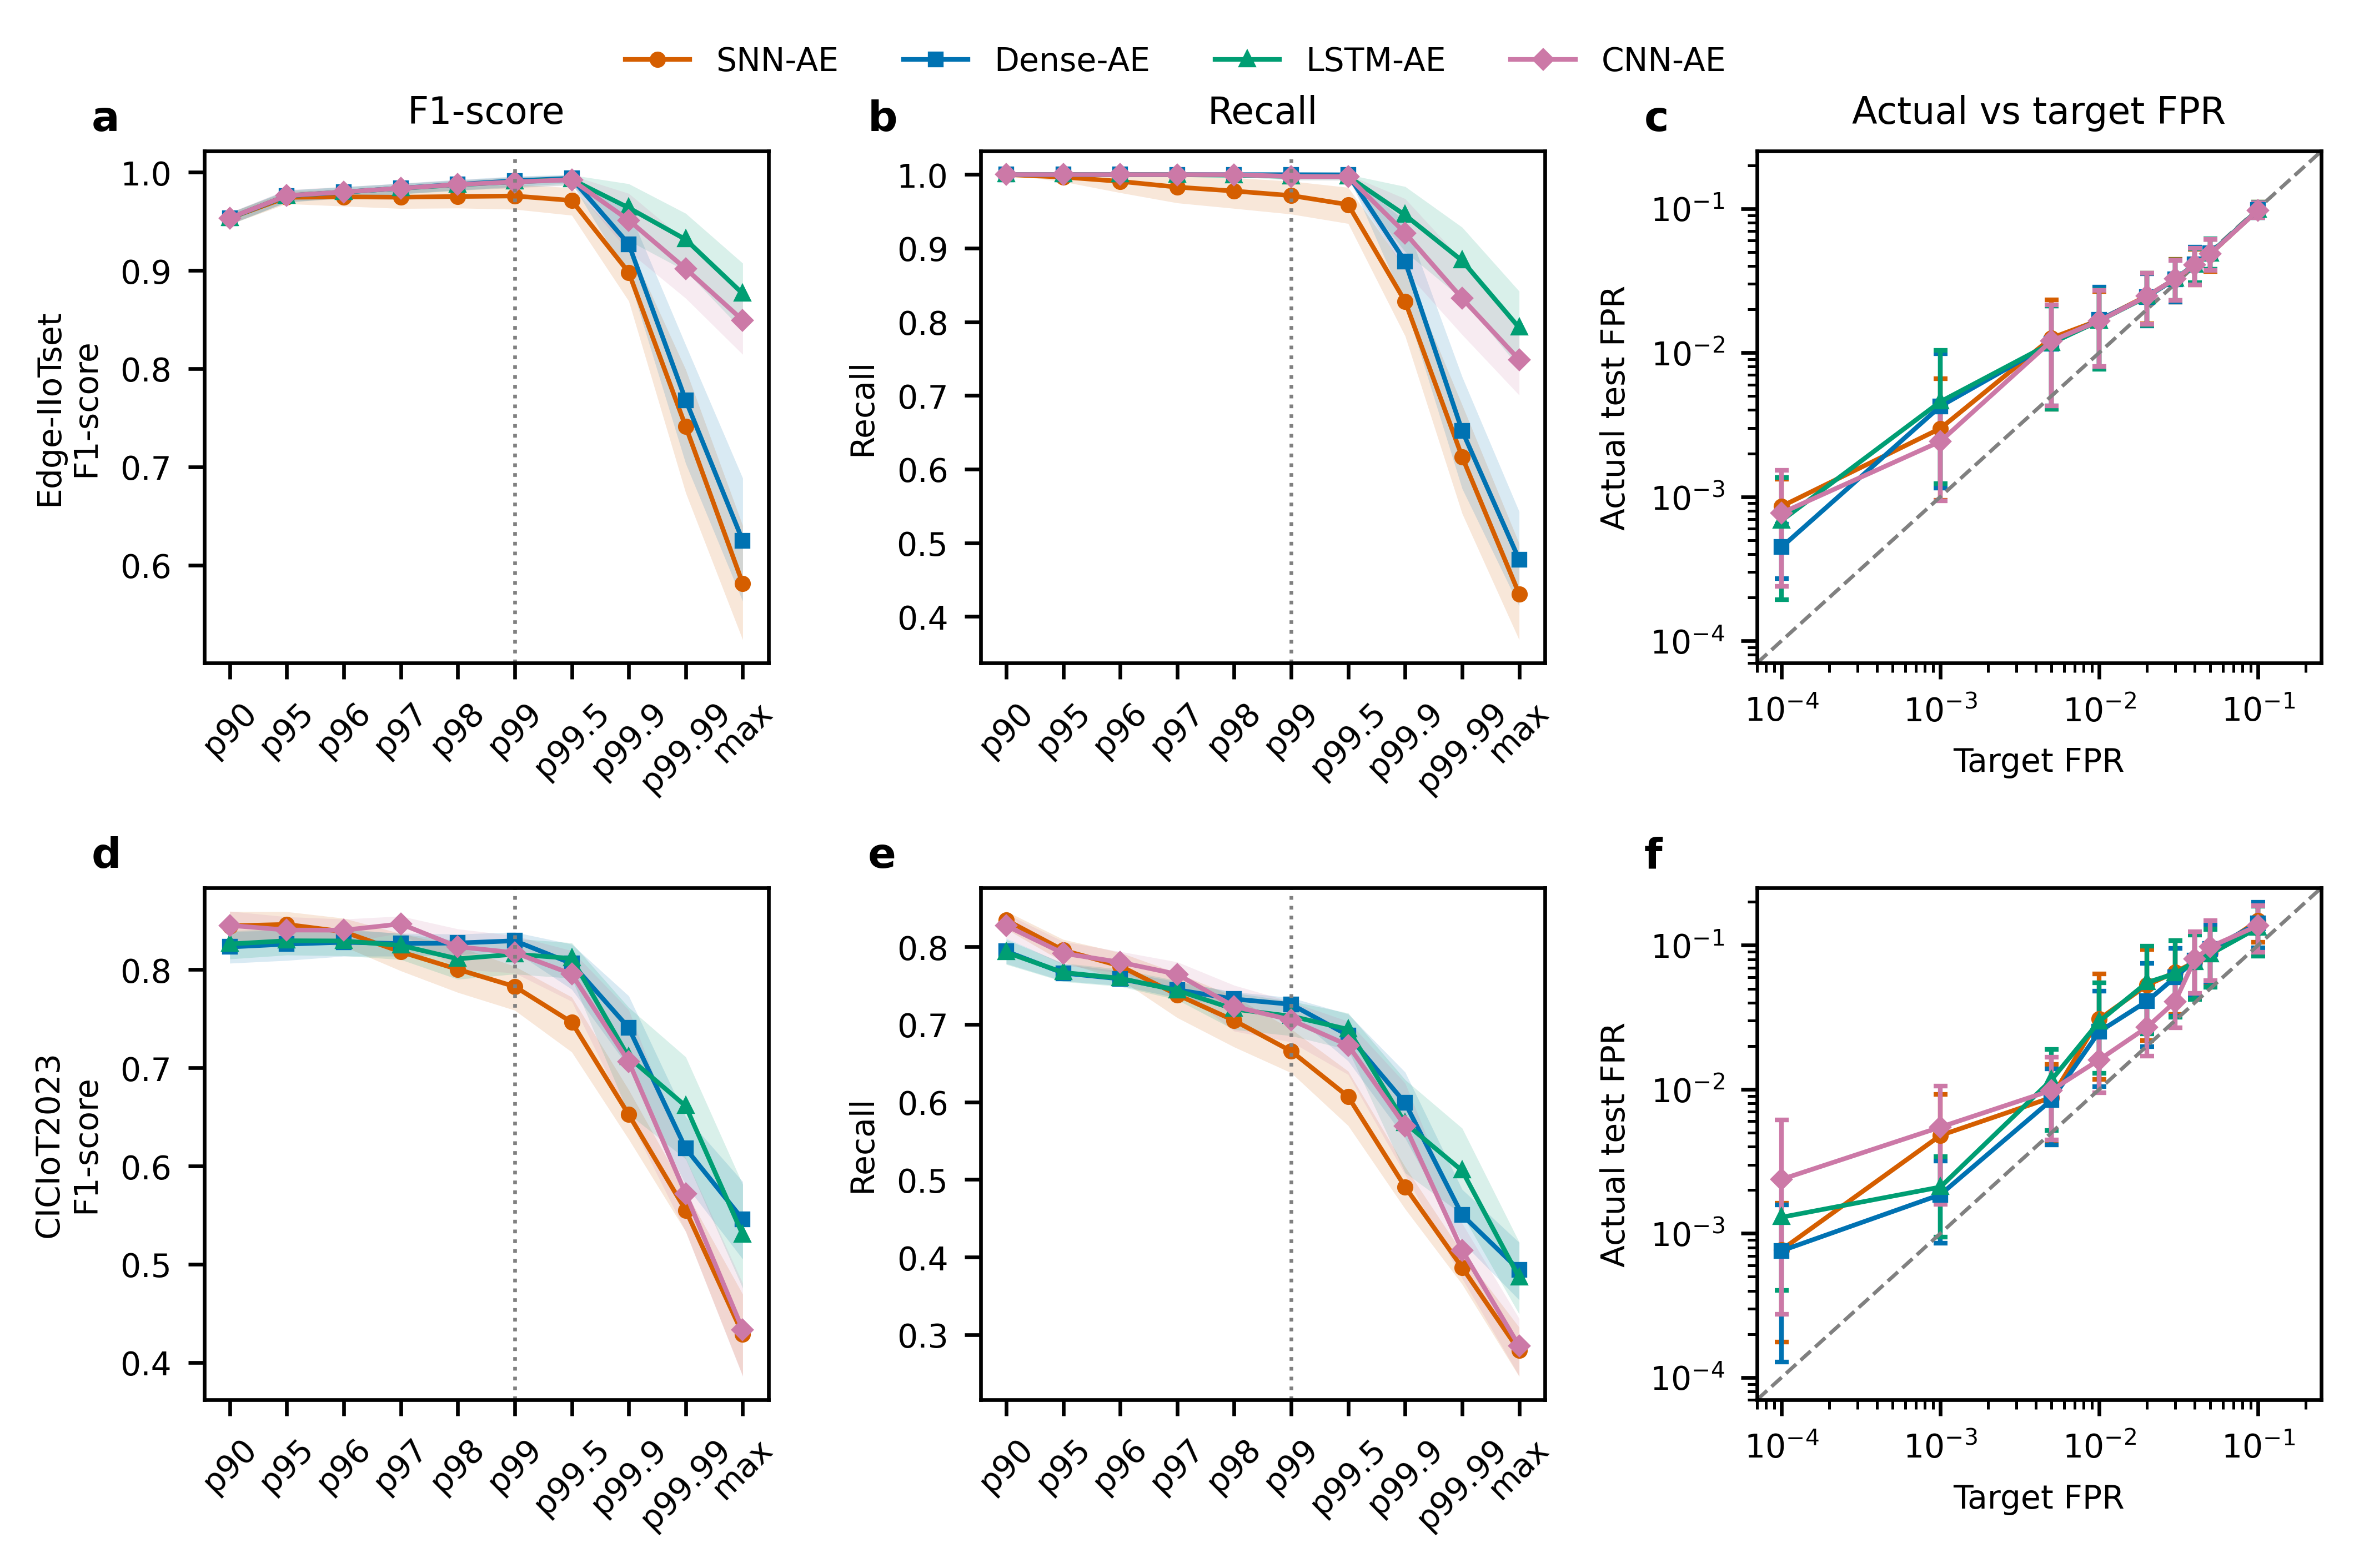

In [7]:
# ======== START: KONFIGURASI FIG 3 ========
import numpy as np, pandas as pd, matplotlib.pyplot as plt, shutil
from pathlib import Path
from IPython.display import Image, display
BASE = Path("/home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision")
REP = BASE / "article-reports"; REP.mkdir(exist_ok=True)
MM = 1 / 25.4
plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
                     "font.size": 7, "axes.titlesize": 8, "legend.fontsize": 7})
DSN = {"edge_iiotset": "Edge-IIoTset", "ciciot2023": "CICIoT2023"}
JOBS = {"SNN_AE": ("SNN-AE", "#D55E00", "o"), "Dense_AE": ("Dense-AE", "#0072B2", "s"),
        "LSTM_AE": ("LSTM-AE", "#009E73", "^"), "CNN_AE": ("CNN-AE", "#CC79A7", "D")}
rng = np.random.default_rng(42)
# ======== END: KONFIGURASI FIG 3 ========

# ======== START: DATA DAN VALIDASI ========
G = pd.read_csv(BASE / "05-tables/threshold_grid_folds.csv")
G["dataset"] = G.dataset.replace({v: k for k, v in DSN.items()})   # label S4 -> kunci
assert set(DSN) <= set(G.dataset), G.dataset.unique()
miss = set(JOBS) - set(G.job); assert not miss, f"job hilang: {miss}"
G["pstr"] = G.percentile.astype(str)
def pkey(p):
    try: return (0, float(p))
    except ValueError: return (1, 0.0)
P = sorted(G.pstr.unique(), key=pkey)
LAB = [f"p{float(p):g}" if pkey(p)[0] == 0 else p for p in P]
G["pi"] = G.pstr.map({p: i for i, p in enumerate(P)})
G = G[G.dataset.isin(DSN) & G.job.isin(JOBS)]
cnt = G.groupby(["dataset", "job", "pi"]).size()
assert (cnt == 30).all(), cnt[cnt != 30]
I99 = next(i for i, p in enumerate(P) if pkey(p) == (0, 99.0))
def ci(x, B=2000):
    x = np.asarray(x, float); b = rng.choice(x, (B, len(x))).mean(1)
    return x.mean(), *np.percentile(b, [2.5, 97.5])
# ======== END: DATA DAN VALIDASI ========

# ======== START: PLOT FIG 3 ========
fig, ax = plt.subplots(2, 3, figsize=(180 * MM, 115 * MM))
x = np.arange(len(P))
for r, ds in enumerate(DSN):
    for job, (lab, col, mk) in JOBS.items():
        S = G[(G.dataset == ds) & (G.job == job)]
        for c, m in enumerate(["f1", "recall"]):
            v = np.array([ci(S[S.pi == i][m]) for i in x])
            ax[r, c].plot(x, v[:, 0], marker=mk, ms=2.5, lw=1, color=col, label=lab)
            ax[r, c].fill_between(x, v[:, 1], v[:, 2], color=col, alpha=.15, lw=0)
        q = S[S.fpr_target > 0].groupby("pi")
        v = np.array([ci(g.fpr_test) for _, g in q]); t = q.fpr_target.first().values
        ax[r, 2].errorbar(t, v[:, 0], yerr=[v[:, 0] - v[:, 1], v[:, 2] - v[:, 0]],
                          marker=mk, ms=2.5, lw=1, color=col, capsize=1.5)
    for c in range(2):
        ax[r, c].set_xticks(x, LAB, rotation=45)
        ax[r, c].axvline(I99, color="grey", ls=":", lw=.8)
    lim = [G[G.fpr_target > 0].fpr_target.min() * .7, 0.25]
    ax[r, 2].plot(lim, lim, color="grey", ls="--", lw=.8)
    ax[r, 2].set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel="Target FPR")
    ax[r, 0].set_ylabel(f"{DSN[ds]}\nF1-score"); ax[r, 1].set_ylabel("Recall")
    ax[r, 2].set_ylabel("Actual test FPR")
for c, t in enumerate(["F1-score", "Recall", "Actual vs target FPR"]):
    ax[0, c].set_title(t)
for k, a in enumerate(ax.flat):
    a.text(-0.2, 1.04, "abcdef"[k], transform=a.transAxes, fontweight="bold", fontsize=9)
h, l = ax[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(.5, 1.03))
fig.tight_layout()
fig.savefig(REP / "fig3.png", dpi=600, bbox_inches="tight"); plt.close(fig)
shutil.copy(BASE / "05-tables/threshold_grid.csv", REP / "tableS_threshold_grid.csv")
print("persentil:", LAB)
display(Image(filename=str(REP / "fig3.png"), width=900))
# ======== END: PLOT FIG 3 ========

CICIoT2023 subtipe terpilih: ['DDoS-ICMP_Flood', 'DDoS-PSHACK_Flood', 'DDoS-SYN_Flood', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood']
Edge-IIoTset subtipe terpilih: ['ddos-http-flood-attacks']


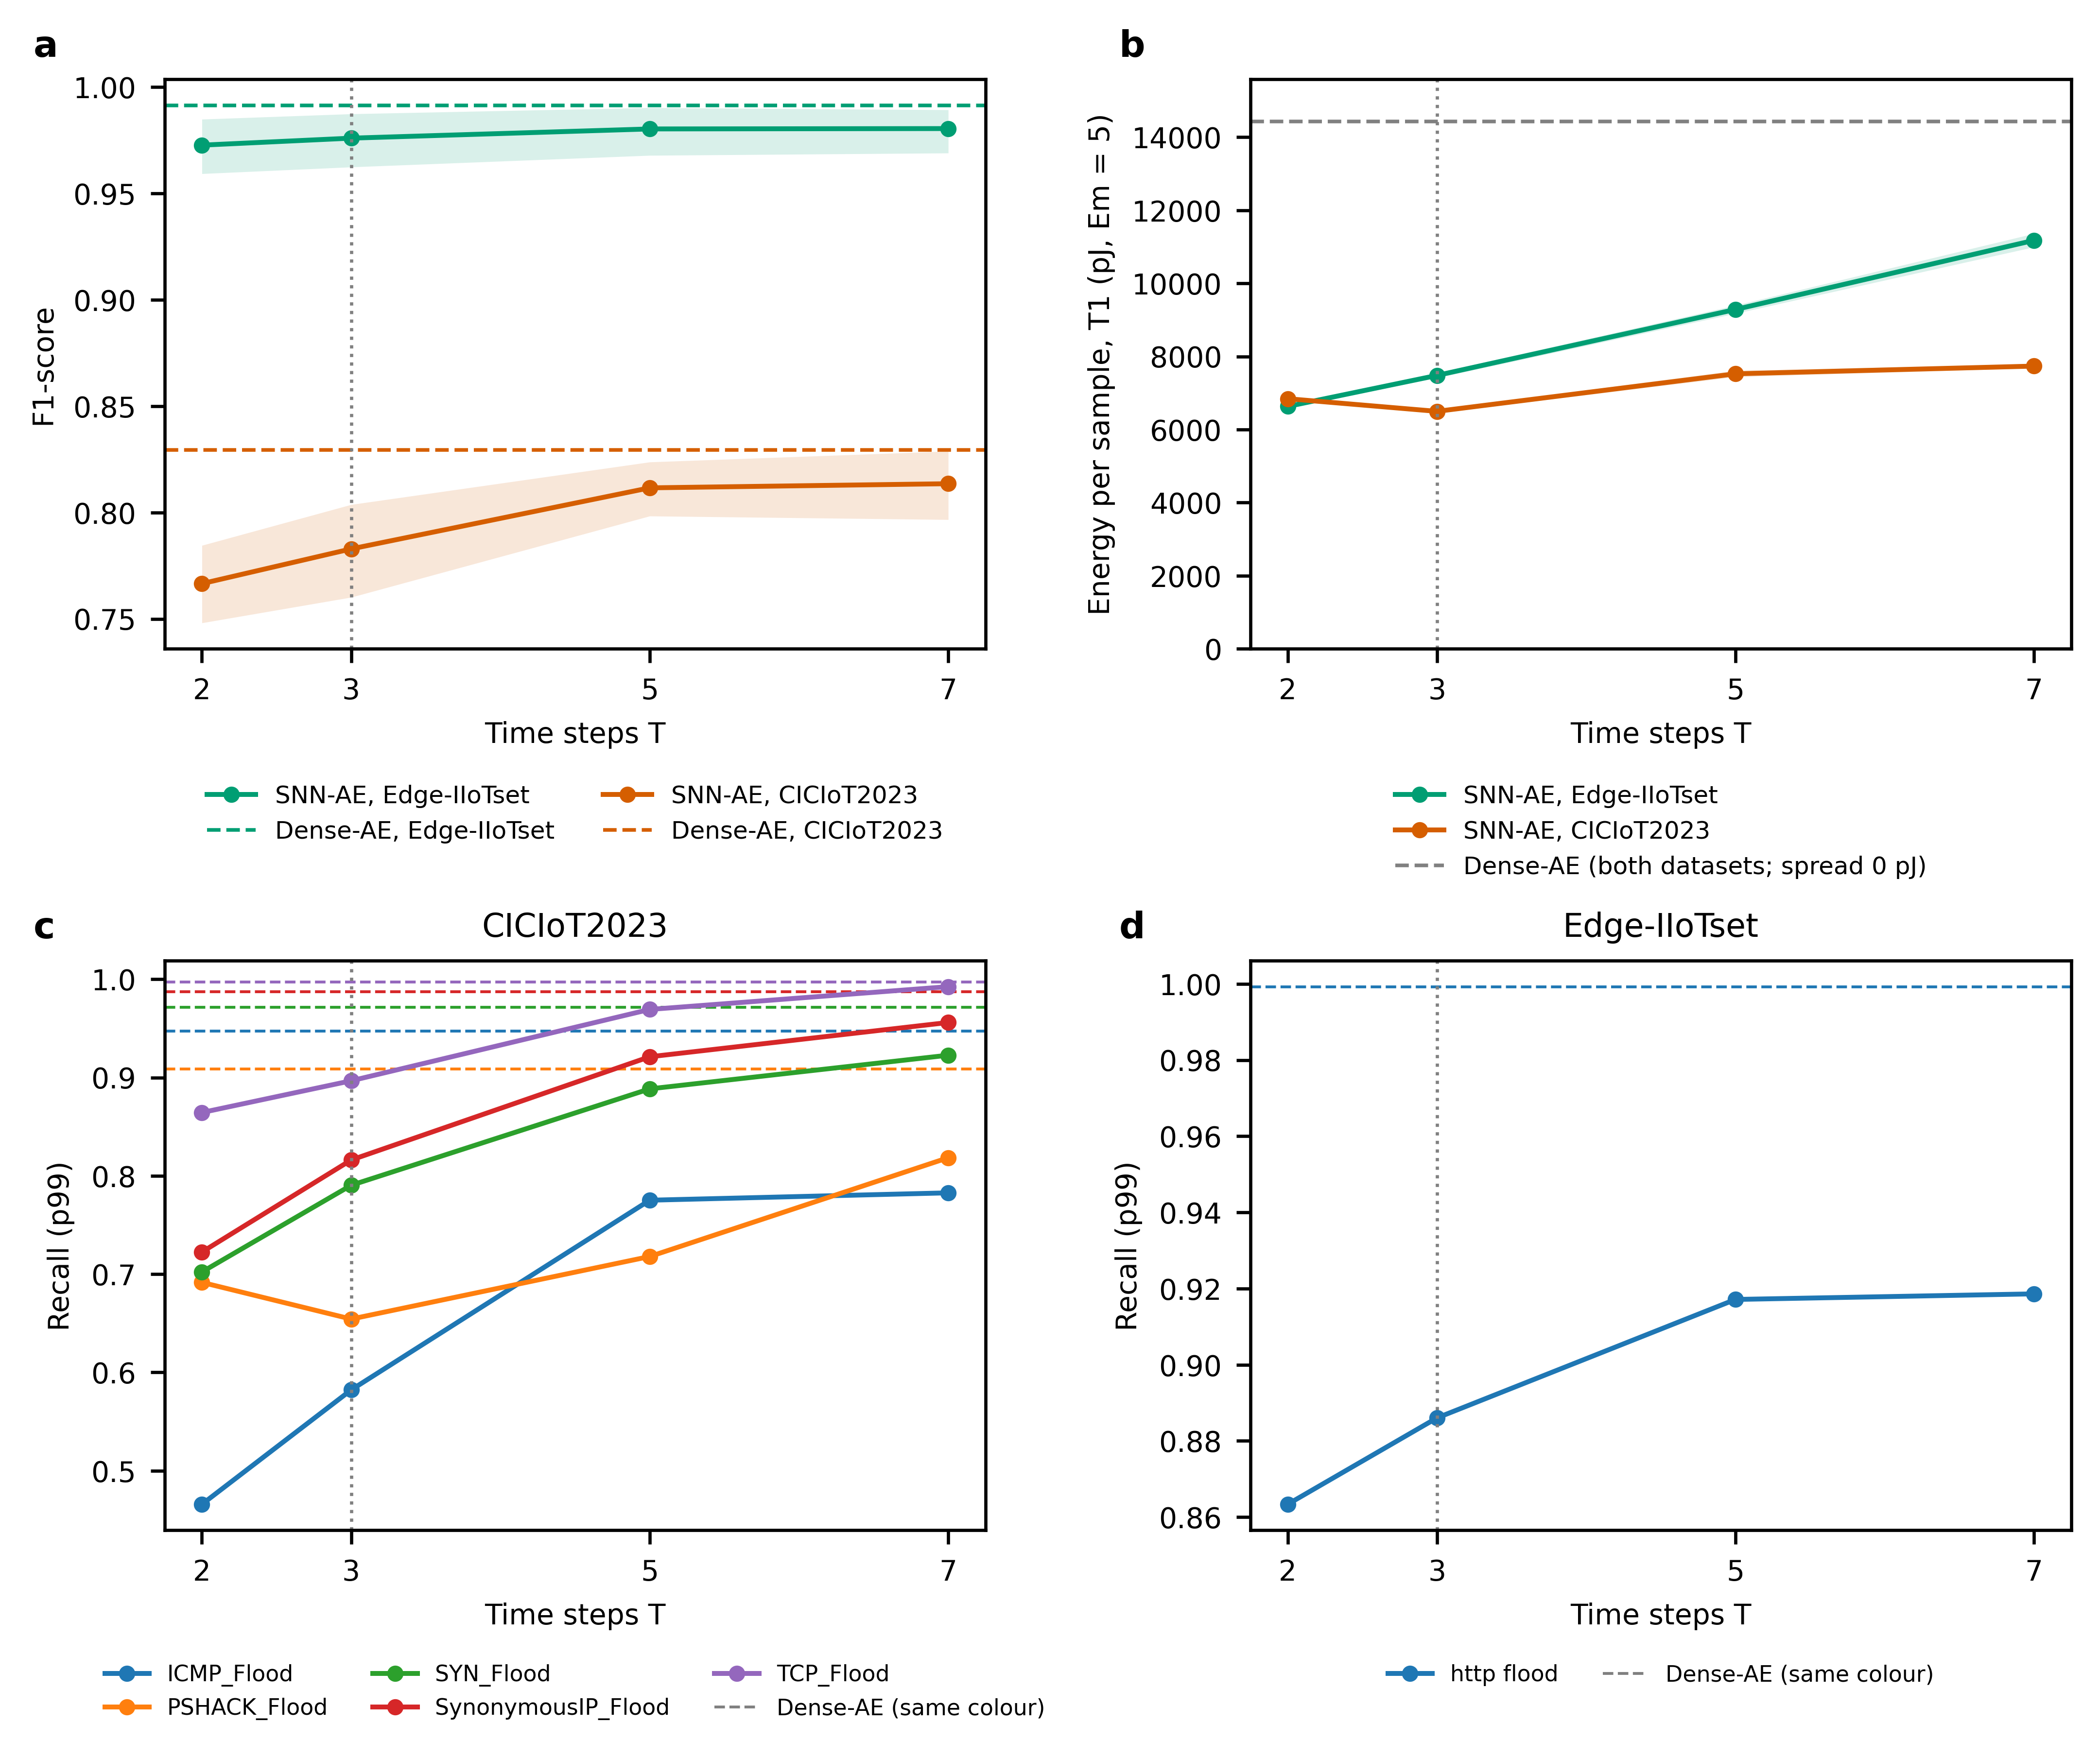

In [11]:
# ======== START: IMPORT ========
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from IPython.display import Image, display
# ======== END: IMPORT ========


# ======== START: KONFIGURASI ========
BASE = Path("/home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision")
REP = BASE / "article-reports"                      # semua gambar/tabel artikel (tanpa subfolder)
OUT_NAME = "fig5.png"                               # UBAH: nama berkas = nomor Fig yang diganti
DPI = 600                                           # UBAH: resolusi PNG
MM = 1 / 25.4
FIG_W, FIG_H = 180, 150                             # UBAH: ukuran gambar (mm); 180 = dua kolom Sci Rep

plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
                     "font.size": 7, "axes.titlesize": 8, "legend.fontsize": 6})  # UBAH: ukuran font

DSN = {"edge_iiotset": "Edge-IIoTset", "ciciot2023": "CICIoT2023"}   # kunci internal -> label
DCOL = {"edge_iiotset": "#009E73", "ciciot2023": "#D55E00"}         # UBAH: warna per dataset (Okabe-Ito)
TJOB = {"SNN_AE_T2": 2, "SNN_AE": 3, "SNN_AE_T5": 5, "SNN_AE_T7": 7}  # job ablasi -> nilai T
T_MAIN = 3                                          # konfigurasi utama (garis titik vertikal)
EM = 5.0                                            # UBAH: Em (pJ) untuk energi T1 (tidak memengaruhi T1)

# Aturan pemilihan subtipe panel (c, d) — ditetapkan a priori, bukan dipilih dari gambar
REC_MIN = 0.5                                       # UBAH: recall Dense minimal
GAP = 0.05                                          # UBAH: selisih minimal SNN (T=3) di bawah Dense

LEG_Y = -0.20                                       # UBAH: posisi legenda di bawah sumbu x (makin negatif = makin turun)
B_BOOT = 2000                                       # UBAH: jumlah resampel bootstrap CI 95%
rng = np.random.default_rng(42)
# ======== END: KONFIGURASI ========


# ======== START: UTILITAS ========
def tokey(s):
    """Label dataset S4/S6 ('Edge-IIoTset') -> kunci internal ('edge_iiotset')."""
    return s.replace({v: k for k, v in DSN.items()})

def ci(x):
    """Rata-rata dan CI 95% bootstrap lintas fold."""
    x = np.asarray(x, float)
    b = rng.choice(x, (B_BOOT, len(x))).mean(1)
    return x.mean(), *np.percentile(b, [2.5, 97.5])

def clean(s):
    """Rapikan nama subtipe untuk legenda."""
    return (s.replace("DDoS-", "").replace("ddos-", "").replace("-attacks", "")
             .replace("-flood", " flood").rstrip("-"))
# ======== END: UTILITAS ========


# ======== START: DATA DAN VALIDASI ========
# Energi + F1 per fold (S6), hanya Em terpilih
E = pd.read_csv(BASE / "07-energy/energy_folds.csv")
E["dataset"] = tokey(E.dataset)
E = E[np.isclose(E.Em, EM) & E.job.isin(list(TJOB) + ["Dense_AE"])]
cnt = E.groupby(["dataset", "job"]).size()
assert len(cnt) == 10 and (cnt == 30).all(), cnt     # 2 dataset x 5 job x 30 fold

# Recall per subtipe (S4, rata-rata 30 fold)
S = pd.read_csv(BASE / "05-tables/subtype_long.csv")
S["dataset"] = tokey(S.dataset)
R = S.pivot_table(index=["dataset", "subtype"], columns="job", values="recall_mean")
assert set(TJOB) | {"Dense_AE"} <= set(R.columns), R.columns
# ======== END: DATA DAN VALIDASI ========


# ======== START: FIGURE ========
fig, ax = plt.subplots(2, 2, figsize=(FIG_W * MM, FIG_H * MM), layout="constrained")
Ts = list(TJOB.values())
# ======== END: FIGURE ========


# ======== START: PANEL (a) F1 vs T DAN (b) ENERGI T1 vs T ========
for ds in DSN:
    for m, a in [("f1", ax[0, 0]), ("T1", ax[0, 1])]:
        v = np.array([ci(E[(E.dataset == ds) & (E.job == j)][m]) for j in TJOB])
        a.plot(Ts, v[:, 0], marker="o", ms=3, lw=1.2, color=DCOL[ds], label=f"SNN-AE, {DSN[ds]}")
        a.fill_between(Ts, v[:, 1], v[:, 2], color=DCOL[ds], alpha=.15, lw=0)
    # acuan Dense-AE per dataset untuk F1
    ax[0, 0].axhline(E[(E.dataset == ds) & (E.job == "Dense_AE")].f1.mean(),
                     color=DCOL[ds], ls="--", lw=.9, label=f"Dense-AE, {DSN[ds]}")

# acuan Dense-AE untuk energi: identik antar-dataset (arsitektur sama) -> satu garis
dE = E[E.job == "Dense_AE"].groupby("dataset").T1.mean()
ax[0, 1].axhline(dE.mean(), color="grey", ls="--", lw=.9,
                 label=f"Dense-AE (both datasets; spread {dE.max() - dE.min():.0f} pJ)")
ax[0, 1].set_ylim(0, dE.max() * 1.08)               # sumbu energi mulai dari 0 (jujur secara visual)

ax[0, 0].set(ylabel="F1-score", xlabel="Time steps T")
ax[0, 1].set(ylabel=f"Energy per sample, T1 (pJ, Em = {EM:g})", xlabel="Time steps T")
ax[0, 0].legend(frameon=False, loc="upper center", bbox_to_anchor=(.5, LEG_Y), ncol=2)
ax[0, 1].legend(frameon=False, loc="upper center", bbox_to_anchor=(.5, LEG_Y))
# ======== END: PANEL (a) DAN (b) ========


# ======== START: PANEL (c) CIC DAN (d) EDGE — RECALL SUBTIPE vs T ========
cmap = plt.get_cmap("tab10")                        # UBAH: palet subtipe
for a, ds in [(ax[1, 0], "ciciot2023"), (ax[1, 1], "edge_iiotset")]:
    r = R.loc[ds]
    sel = r[(r.Dense_AE >= REC_MIN) & (r.SNN_AE < r.Dense_AE - GAP)].index.tolist()
    print(DSN[ds], "subtipe terpilih:", sel)
    for i, s in enumerate(sel):
        c = cmap(i % 10)
        a.plot(Ts, [r.loc[s, j] for j in TJOB], marker="o", ms=3, lw=1.2, color=c, label=clean(s))
        a.axhline(r.loc[s, "Dense_AE"], color=c, ls="--", lw=.7)   # Dense-AE, warna sama
    if not sel:
        a.text(.5, .5, "No subtype met the selection rule", ha="center", transform=a.transAxes)
    h, l = a.get_legend_handles_labels()
    h.append(Line2D([], [], color="grey", ls="--", lw=.7)); l.append("Dense-AE (same colour)")
    a.legend(h, l, frameon=False, fontsize=5.5, loc="upper center",
             bbox_to_anchor=(.5, LEG_Y), ncol=3)
    a.set(ylabel="Recall (p99)", xlabel="Time steps T", title=DSN[ds])
# ======== END: PANEL (c) DAN (d) ========


# ======== START: FORMAT UMUM DAN SIMPAN ========
for k, a in enumerate(ax.flat):
    a.set_xticks(Ts)
    a.axvline(T_MAIN, color="grey", ls=":", lw=.8)  # konfigurasi utama T = 3
    a.text(-0.16, 1.04, "abcd"[k], transform=a.transAxes,
           fontweight="bold", fontsize=9)            # UBAH: posisi label panel
fig.savefig(REP / OUT_NAME, dpi=DPI, bbox_inches="tight"); plt.close(fig)
display(Image(filename=str(REP / OUT_NAME), width=900))
# ======== END: FORMAT UMUM DAN SIMPAN ========

E_MAC=4.6 E_AC=0.9 E_LIF=0.1
validasi komponen vs S6: OK (T2, T3_opt, T3_pess, T1 Dense)
dataset       job     
ciciot2023    Dense_AE    22217.0
              SNN_AE      23088.0
edge_iiotset  Dense_AE    25155.0
              SNN_AE      29531.0
dtype: float64


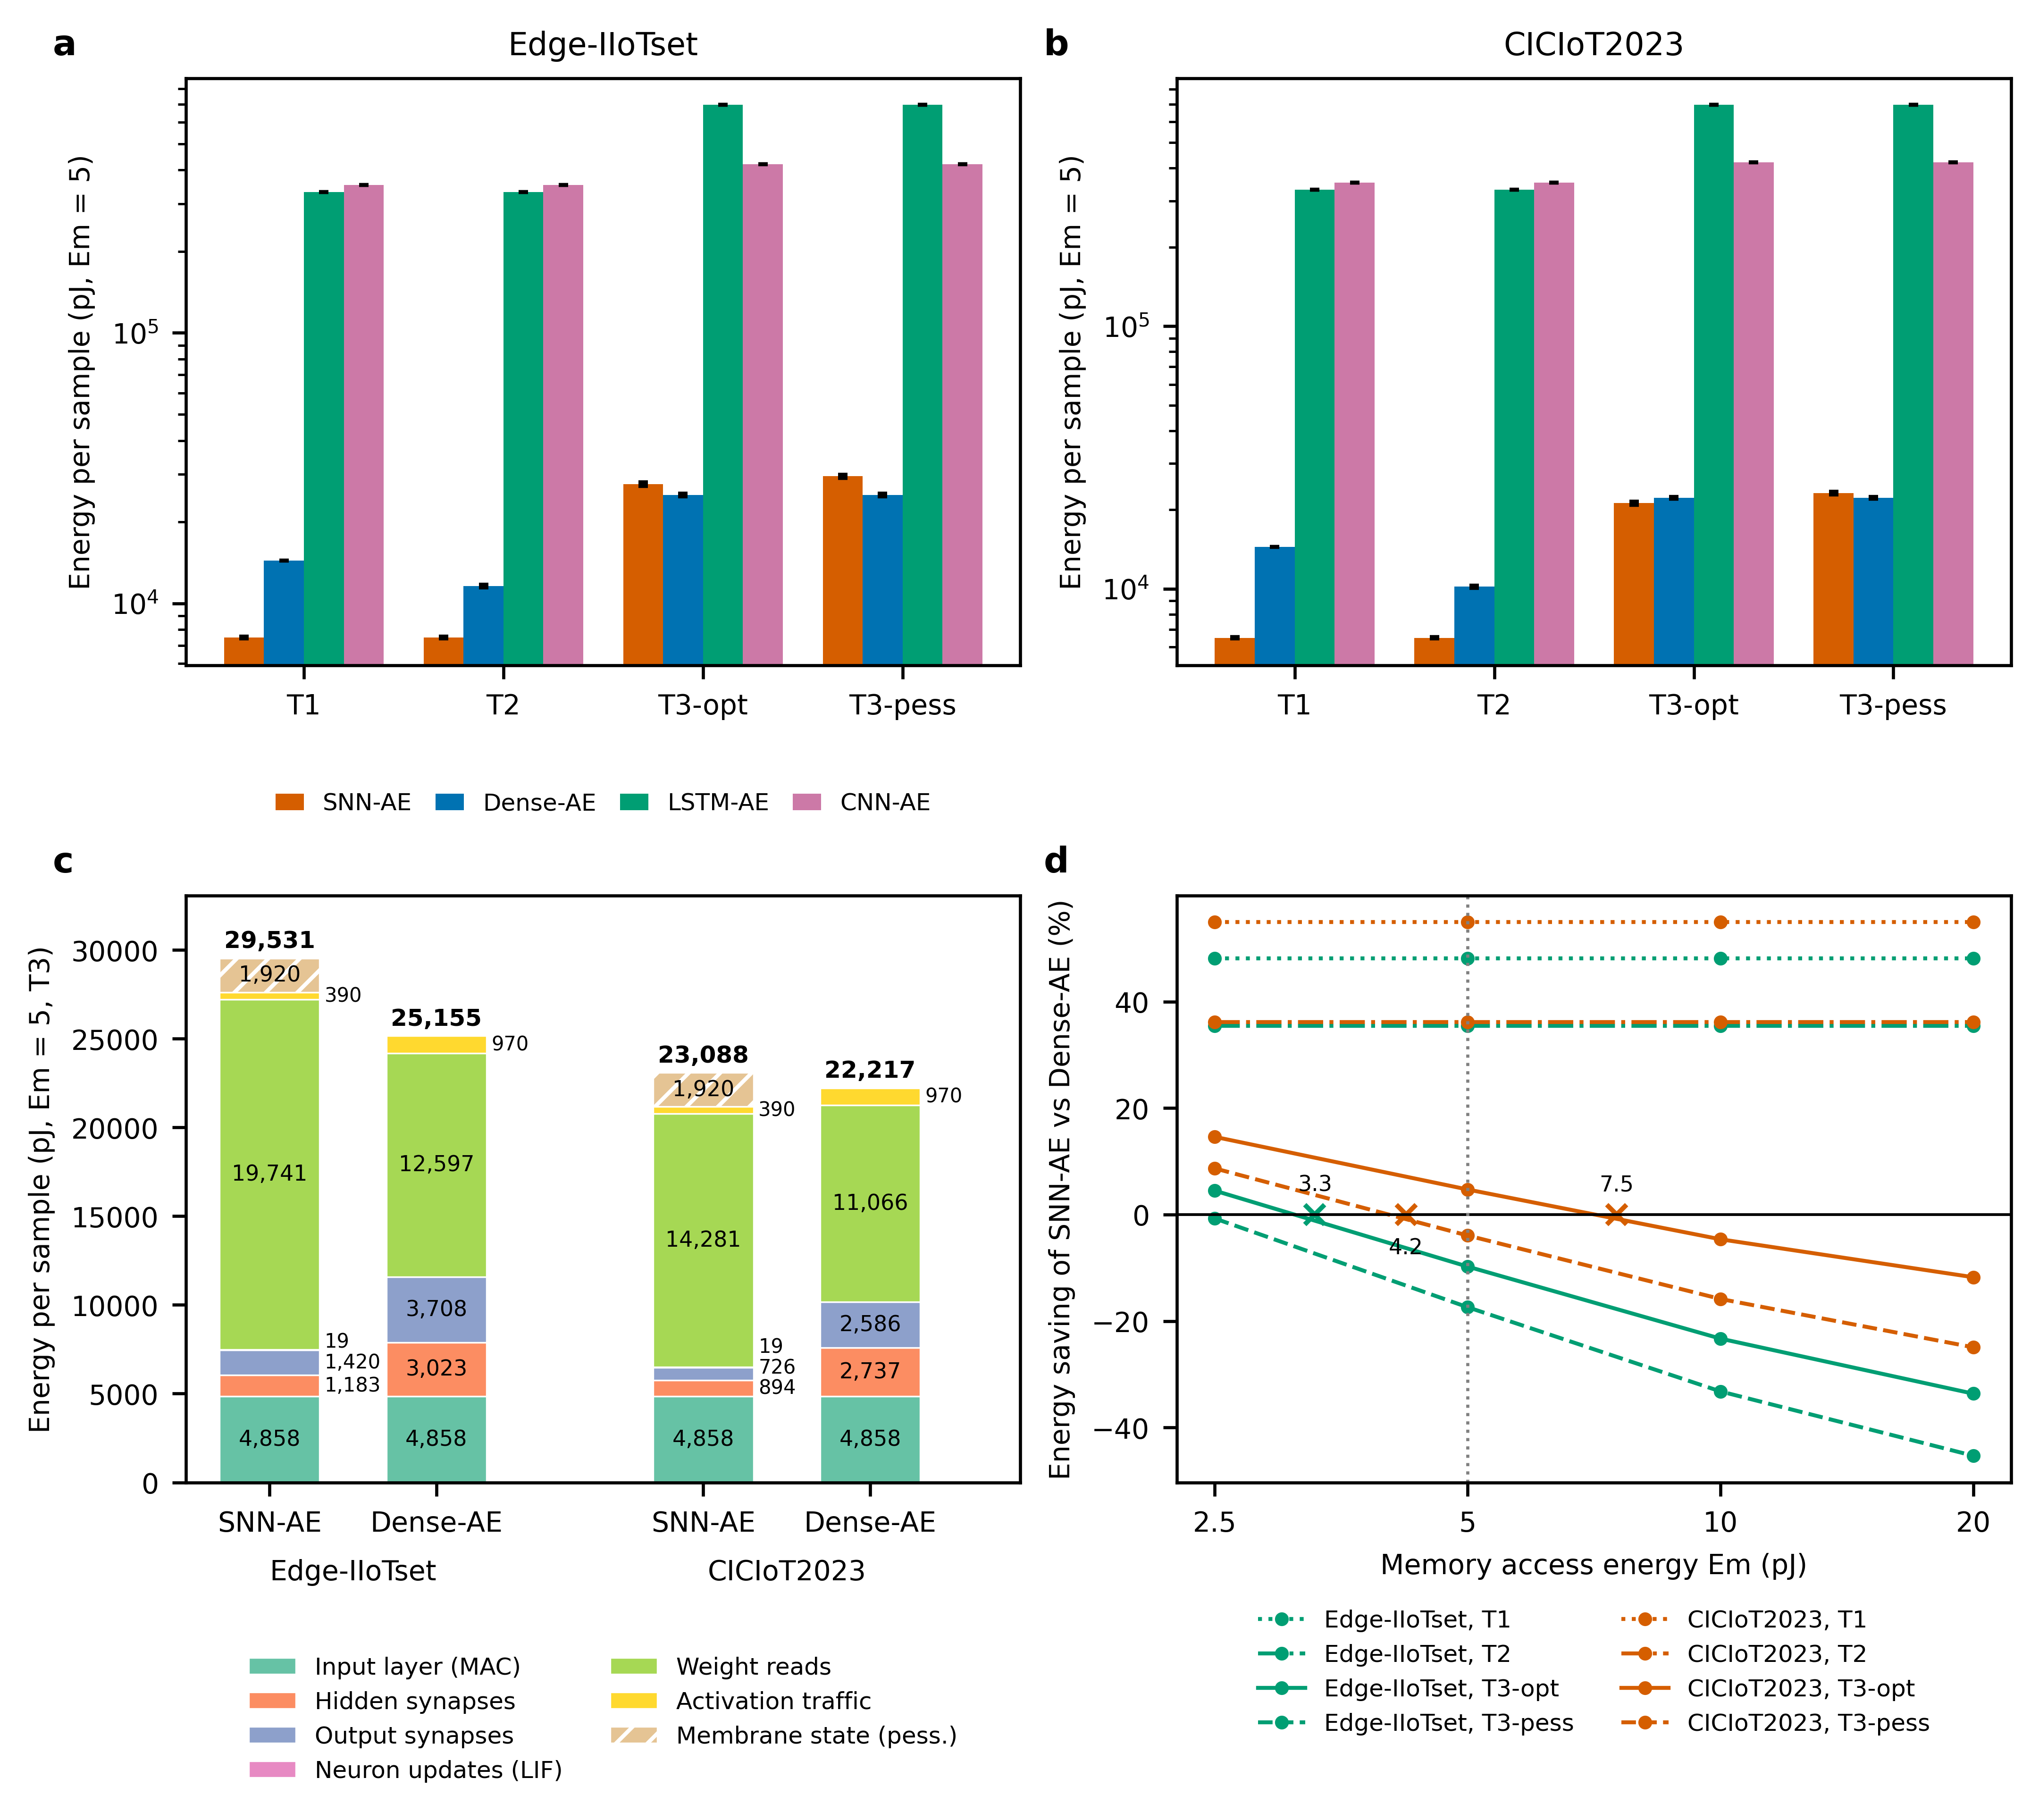

In [14]:
# ======== START: IMPORT ========
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt, shutil
from pathlib import Path
from IPython.display import Image, display
# ======== END: IMPORT ========


# ======== START: KONFIGURASI ========
BASE = Path("/home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision")
REP = BASE / "article-reports"
OUT_NAME = "fig4.png"                               # UBAH: nama berkas = nomor Fig yang diganti
DPI = 600                                           # UBAH: resolusi PNG
MM = 1 / 25.4
FIG_W, FIG_H = 180, 160                             # UBAH: ukuran gambar (mm)
plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
                     "font.size": 7, "axes.titlesize": 8, "legend.fontsize": 6})

DSN = {"edge_iiotset": "Edge-IIoTset", "ciciot2023": "CICIoT2023"}
DCOL = {"edge_iiotset": "#009E73", "ciciot2023": "#D55E00"}          # warna dataset (sama dgn Fig. 5)
MODELS = {"SNN_AE": ("SNN-AE", "#D55E00"), "Dense_AE": ("Dense-AE", "#0072B2"),
          "LSTM_AE": ("LSTM-AE", "#009E73"), "CNN_AE": ("CNN-AE", "#CC79A7")}  # sama dgn Fig. 3
TIERS = {"T1": "T1", "T2": "T2", "T3_opt": "T3-opt", "T3_pess": "T3-pess"}
EM = 5.0                                            # UBAH: Em utama (pJ)
L, DIN, DOUT = 32, 33, 33                           # dimensi laten, input, output (divalidasi di bawah)
LEG_Y = -0.18                                       # UBAH: posisi legenda di bawah sumbu x
SMALL = 0.06                                        # UBAH: segmen < 6% tinggi batang diberi label di samping
B_BOOT = 2000
rng = np.random.default_rng(42)

# Konstanta energi dari config (fallback = nilai S3/S6: Horowitz 45 nm)
CFG = json.loads((BASE / "00-config/config_revision.json").read_text())
EC = CFG.get("energy", {})
E_MAC, E_AC, E_LIF = EC.get("E_MAC", 4.6), EC.get("E_AC", 0.9), EC.get("E_LIF", 0.1)
print(f"E_MAC={E_MAC} E_AC={E_AC} E_LIF={E_LIF}")
# ======== END: KONFIGURASI ========


# ======== START: UTILITAS ========
def tokey(s):
    return s.replace({v: k for k, v in DSN.items()})

def ci(x):
    x = np.asarray(x, float)
    b = rng.choice(x, (B_BOOT, len(x))).mean(1)
    return x.mean(), *np.percentile(b, [2.5, 97.5])

def components(job, r, em):
    """Rumus identik dengan energy_spiking/energy_dense di S6 (tingkat T2 + memori)."""
    wi, wint, wo = DIN * L, L * L, L * DOUT
    if job == "SNN_AE":
        T = r["T"]
        reads = wi + r["k_enc"] * wint + r["k_dec"] * wo
        return {"Input layer (MAC)": wi * E_MAC,
                "Hidden synapses": r["k_enc"] * wint * E_AC,
                "Output synapses": r["k_dec"] * wo * E_AC,
                "Neuron updates (LIF)": 2 * L * T * E_LIF,
                "Weight reads": em * reads,
                "Activation traffic": em * (DIN + DOUT + 2 * 2 * L * T / 32),
                "Membrane state (pess.)": em * 2 * 2 * L * T}
    reads = wi + (1 - r["s_enc"]) * wint + (1 - r["s_dec"]) * wo   # Dense_AE
    return {"Input layer (MAC)": wi * E_MAC,
            "Hidden synapses": (1 - r["s_enc"]) * wint * E_MAC,
            "Output synapses": (1 - r["s_dec"]) * wo * E_MAC,
            "Neuron updates (LIF)": 0.0,
            "Weight reads": em * reads,
            "Activation traffic": em * (DIN + DOUT + 2 * 2 * L),
            "Membrane state (pess.)": 0.0}
COMP = list(components("SNN_AE", {"T": 3, "k_enc": 0, "k_dec": 0}, 0))
ARITH = COMP[:4]                                    # komponen aritmetika (= T2)
# ======== END: UTILITAS ========


# ======== START: DATA ========
EF = pd.read_csv(BASE / "07-energy/energy_folds.csv"); EF["dataset"] = tokey(EF.dataset)
EF5 = EF[np.isclose(EF.Em, EM) & EF.job.isin(MODELS)]
cnt = EF5.groupby(["dataset", "job"]).size()
assert len(cnt) == 8 and (cnt == 30).all(), cnt

SS = pd.read_csv(BASE / "07-energy/spike_sparsity_folds.csv"); SS["dataset"] = tokey(SS.dataset)
TS = pd.read_csv(BASE / "07-energy/energy_tests_snn_vs_dense.csv"); TS["dataset"] = tokey(TS.dataset)
# ======== END: DATA ========


# ======== START: KOMPONEN + VALIDASI TERHADAP S6 ========
key = ["dataset", "job", "seed", "fold"]
M = EF5[EF5.job.isin(["SNN_AE", "Dense_AE"])].merge(
        SS[key + ["T", "k_enc", "k_dec", "s_enc", "s_dec"]], on=key, how="left", validate="1:1")
C = pd.DataFrame([components(r["job"], r, EM) for r in M.to_dict("records")])   # r = dict
M = pd.concat([M.reset_index(drop=True), C], axis=1)
chk = {"T2": M[ARITH].sum(1),
       "T3_opt": M[COMP[:6]].sum(1),
       "T3_pess": M[COMP].sum(1)}
for t, v in chk.items():
    rel = np.abs(v - M[t]) / M[t]
    assert rel.max() < 1e-6, f"{t}: selisih maks {rel.max():.2e}\n{M.loc[rel.idxmax(), key]}"
d = M.job == "Dense_AE"
assert np.allclose(M.loc[d, "T1"], (DIN * L + L * L + L * DOUT) * E_MAC)
print("validasi komponen vs S6: OK (T2, T3_opt, T3_pess, T1 Dense)")
CM = M.groupby(["dataset", "job"])[COMP].mean()     # rata-rata 30 fold
CM.round(1).to_csv(REP / "tableS_energy_components_Em5.csv")
# ======== END: KOMPONEN + VALIDASI TERHADAP S6 ========


# ======== START: FIGURE ========
fig, ax = plt.subplots(2, 2, figsize=(FIG_W * MM, FIG_H * MM), layout="constrained")
# ======== END: FIGURE ========

# ======== START: PANEL (a, b) ENERGI PER TINGKAT ========
w = 0.2                                             # UBAH: lebar batang
xt = np.arange(len(TIERS))
for a, ds in [(ax[0, 0], "edge_iiotset"), (ax[0, 1], "ciciot2023")]:
    for i, (job, (lab, col)) in enumerate(MODELS.items()):
        X = EF5[(EF5.dataset == ds) & (EF5.job == job)]
        v = np.array([ci(X[t]) for t in TIERS])
        a.bar(xt + (i - 1.5) * w, v[:, 0], w, color=col, label=lab,
              yerr=[v[:, 0] - v[:, 1], v[:, 2] - v[:, 0]], capsize=1.2,
              error_kw={"lw": .6})
    a.set(yscale="log", xticks=xt, xticklabels=list(TIERS.values()),
          ylabel=f"Energy per sample (pJ, Em = {EM:g})", title=DSN[ds])
ax[0, 0].legend(frameon=False, loc="upper center", bbox_to_anchor=(.5, LEG_Y), ncol=4,
                handlelength=1.2, columnspacing=1)  # legenda di bawah (a), tidak keluar sumbu
# ======== END: PANEL (a, b) ========


# ======== START: PANEL (c) KOMPONEN (R3.12) ========
a = ax[1, 0]
ccol = plt.get_cmap("Set2")                         # UBAH: palet komponen
bars = [(ds, job) for ds in DSN for job in ["SNN_AE", "Dense_AE"]]
GROUP_GAP = 0.6                                     # UBAH: jarak tambahan antar-grup dataset
xb = np.array([i + (i // 2) * GROUP_GAP for i in range(len(bars))])
ymax = CM.sum(1).max() * 1.12
for j, (ds, job) in enumerate(bars):
    vals, bottom, small = CM.loc[(ds, job)], 0.0, []
    tot = vals.sum()
    for c_i, comp in enumerate(COMP):
        v = vals[comp]
        if v <= 0: continue
        a.bar(xb[j], v, .6, bottom=bottom, color=ccol(c_i), edgecolor="white", lw=.4,
              hatch="///" if "Membrane" in comp else None,
              label=comp if j == 0 else None)
        if v / tot >= SMALL:
            a.text(xb[j], bottom + v / 2, f"{v:,.0f}", ha="center", va="center", fontsize=5.5)
        else:
            small.append((bottom + v / 2, f"{v:,.0f}"))
        bottom += v
    ys, gap = [], ymax * .035                       # label segmen kecil: di kanan, tidak bertumpuk
    for y, t in sorted(small):
        y = max(y, ys[-1] + gap) if ys else y; ys.append(y)
        a.text(xb[j] + .33, y, t, ha="left", va="center", fontsize=5)
    a.text(xb[j], tot + ymax * .01, f"{tot:,.0f}", ha="center", va="bottom",
           fontsize=6, fontweight="bold")
a.set(xticks=xb, xticklabels=[MODELS[j][0] for _, j in bars],
      xlim=(xb[0] - .5, xb[-1] + .9), ylim=(0, ymax),
      ylabel=f"Energy per sample (pJ, Em = {EM:g}, T3)")
for g, ds in enumerate(DSN):                         # label grup dataset di bawah tick
    a.text(xb[2 * g:2 * g + 2].mean(), -0.13, DSN[ds], transform=a.get_xaxis_transform(),
           ha="center", va="top", fontsize=7)
h, l = a.get_legend_handles_labels()
a.legend(h, l, frameon=False, loc="upper center", bbox_to_anchor=(.5, LEG_Y - .08), ncol=2)
# ======== END: PANEL (c) ========


# ======== START: PANEL (d) PENGHEMATAN vs Em ========
from matplotlib.ticker import NullFormatter, NullLocator
a = ax[1, 1]
for ds in DSN:
    for tier, ls in [("T1", ":"), ("T2", "-."), ("T3_opt", "-"), ("T3_pess", "--")]:
        X = TS[(TS.dataset == ds) & (TS.tier == tier)].sort_values("Em")
        a.plot(X.Em, X.saving_pct, ls=ls, marker="o", ms=2.5, lw=1, color=DCOL[ds],
               label=f"{DSN[ds]}, {TIERS[tier]}")
        e, s = X.Em.values, X.saving_pct.values     # titik silang (interpolasi linear)
        for i in range(len(e) - 1):
            if s[i] * s[i + 1] < 0:
                ex = e[i] + (e[i + 1] - e[i]) * s[i] / (s[i] - s[i + 1])
                a.plot(ex, 0, marker="x", color=DCOL[ds], ms=5, mew=1.2)
                a.annotate(f"{ex:.1f}", (ex, 0), textcoords="offset points",
                           xytext=(0, 6 if tier == "T3_opt" else -10), ha="center", fontsize=5.5)
a.axhline(0, color="black", lw=.7); a.axvline(EM, color="grey", ls=":", lw=.8)
EMS = sorted(TS.Em.unique())
a.set(xscale="log", xlabel="Memory access energy Em (pJ)",
      ylabel="Energy saving of SNN-AE vs Dense-AE (%)")
a.xaxis.set_minor_locator(NullLocator()); a.xaxis.set_minor_formatter(NullFormatter())
a.set_xticks(EMS, [f"{x:g}" for x in EMS])          # hanya tick Em yang diuji
a.legend(frameon=False, loc="upper center", bbox_to_anchor=(.5, LEG_Y), ncol=2)
# ======== END: PANEL (d) ========


# ======== START: FORMAT UMUM, SIMPAN, TABEL ========
for k, a in enumerate(ax.flat):
    a.text(-0.16, 1.04, "abcd"[k], transform=a.transAxes, fontweight="bold", fontsize=9)
fig.savefig(REP / OUT_NAME, dpi=DPI, bbox_inches="tight"); plt.close(fig)
for f in ["energy_summary_Em5.csv", "energy_tests_snn_vs_dense.csv", "break_even.csv"]:
    shutil.copy(BASE / "07-energy" / f, REP / f"tableS_{f}")
print(CM.sum(1).round(0))                           # total T3-pess per batang (cek cepat)
display(Image(filename=str(REP / OUT_NAME), width=900))
# ======== END: FORMAT UMUM, SIMPAN, TABEL ========

trial pilot per dataset: {'ciciot2023': 40, 'edge_iiotset': 40}


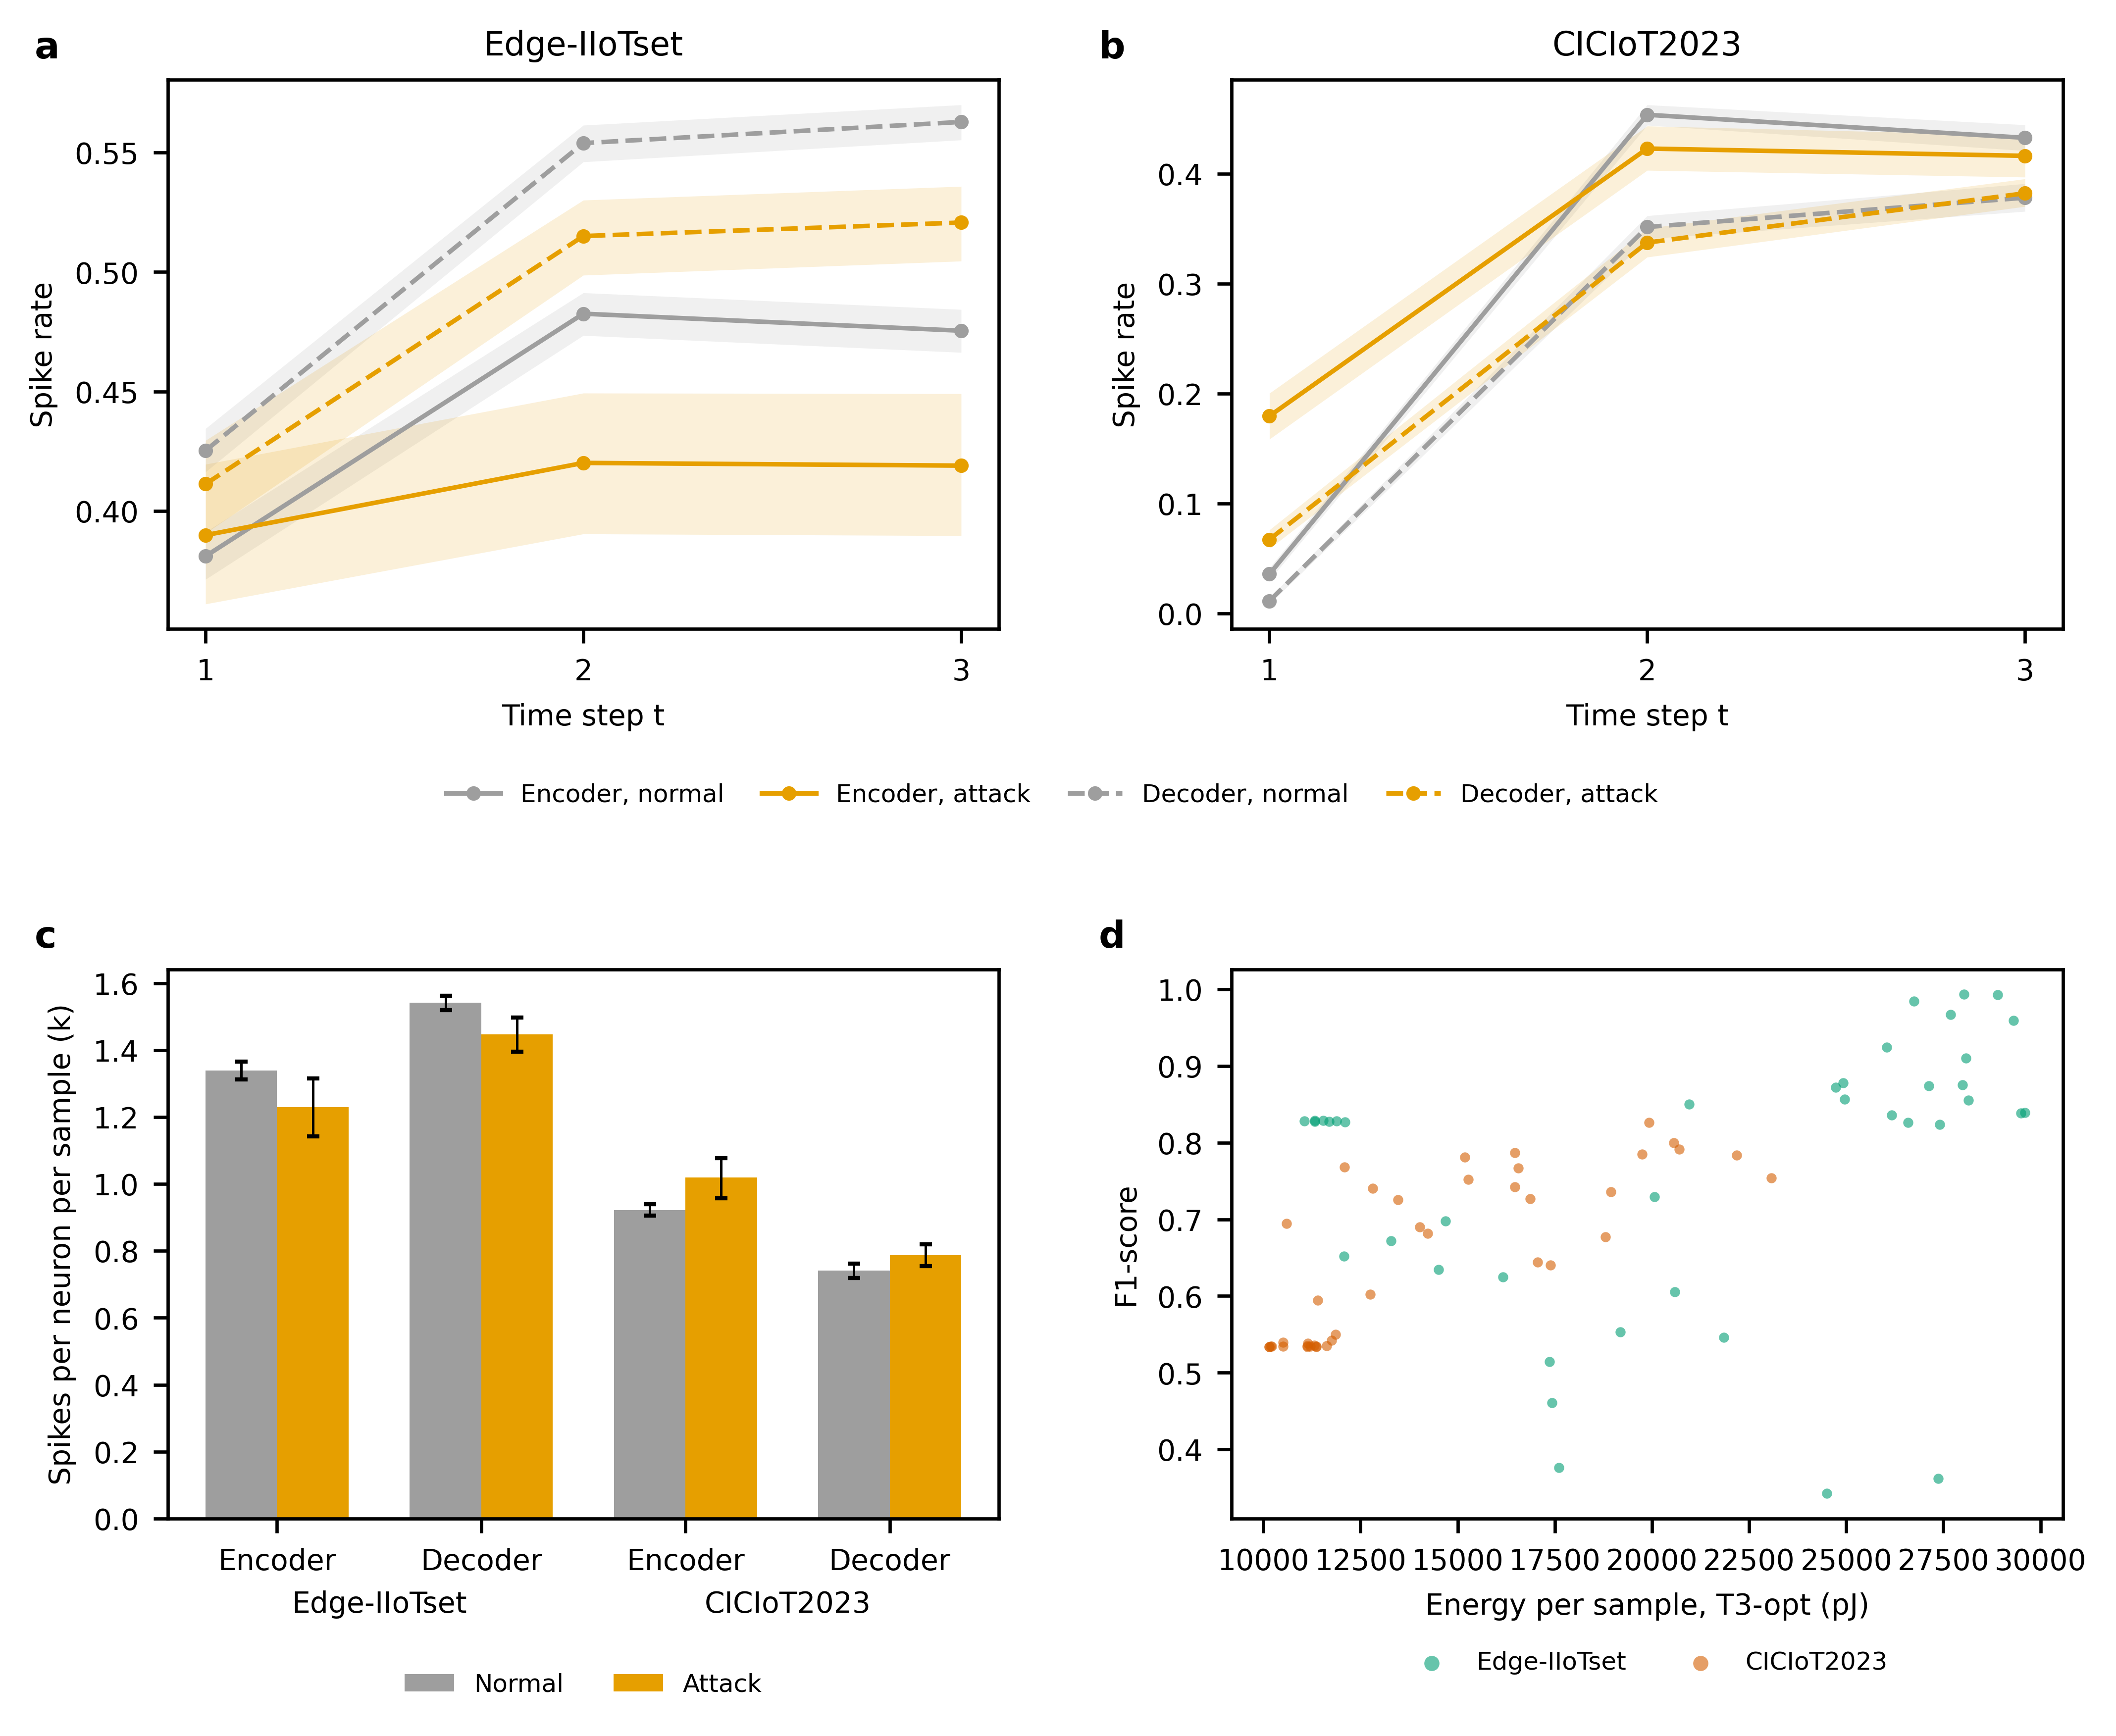

In [16]:
# ======== START: IMPORT ========
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display
# ======== END: IMPORT ========


# ======== START: KONFIGURASI ========
BASE = Path("/home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision")
REP = BASE / "article-reports"
OUT_NAME = "figS_spike.png"                         # UBAH: nama berkas
DPI = 600                                           # UBAH: resolusi PNG
MM = 1 / 25.4
FIG_W, FIG_H = 180, 150                             # UBAH: ukuran gambar (mm)
plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
                     "font.size": 7, "axes.titlesize": 8, "legend.fontsize": 6})

# Tata letak manual (tanpa constrained layout agar legenda lebar tidak melebarkan kolom)
LEFT, RIGHT, TOP, BOTTOM = 0.08, 0.98, 0.95, 0.13   # UBAH: margin figure (fraksi 0–1)
WSPACE = 0.28                                       # UBAH: jarak antar-kolom (a–b, c–d)
HSPACE = 0.62                                       # UBAH: jarak antar-baris (ruang untuk legenda a/b)
LEG_TOP_OFFSET = 0.075                              # UBAH: jarak legenda a/b di bawah sumbu baris atas
LEG_Y = -0.20                                       # UBAH: posisi legenda panel c dan d (koordinat sumbu)

DSN = {"edge_iiotset": "Edge-IIoTset", "ciciot2023": "CICIoT2023"}
DCOL = {"edge_iiotset": "#009E73", "ciciot2023": "#D55E00"}          # warna dataset
CCOL = {"normal": "#9E9E9E", "attack": "#E69F00"}                    # warna kelas (sama dgn UMAP)
LSTY = {"encoder": "-", "decoder": "--"}                             # gaya garis per lapisan
JOB = "SNN_AE"                                      # konfigurasi utama
B_BOOT = 2000                                       # UBAH: resampel bootstrap CI 95%
rng = np.random.default_rng(42)
# ======== END: KONFIGURASI ========


# ======== START: UTILITAS ========
def tokey(s):
    """Label dataset S6 ('Edge-IIoTset') -> kunci internal ('edge_iiotset')."""
    return s.replace({v: k for k, v in DSN.items()})

def ci(x):
    """Rata-rata dan CI 95% bootstrap lintas fold."""
    x = np.asarray(x, float)
    b = rng.choice(x, (B_BOOT, len(x))).mean(1)
    return x.mean(), *np.percentile(b, [2.5, 97.5])
# ======== END: UTILITAS ========


# ======== START: DATA DAN VALIDASI ========
RT = pd.read_csv(BASE / "07-energy/spike_rate_per_timestep_folds.csv"); RT["dataset"] = tokey(RT.dataset)
RT = RT[RT.job == JOB]
cnt = RT.groupby(["dataset", "layer", "class", "t"]).size()
assert (cnt == 30).all(), cnt[cnt != 30]

SP = pd.read_csv(BASE / "07-energy/spike_sparsity_folds.csv"); SP["dataset"] = tokey(SP.dataset)
SP = SP[SP.job == JOB]
assert (SP.groupby("dataset").size() == 30).all()

PL = pd.concat([pd.read_csv(BASE / f"07-energy/pilot_points_{ds}.csv") for ds in DSN])
PL["dataset"] = tokey(PL.dataset.astype(str))
print("trial pilot per dataset:", PL.groupby("dataset").size().to_dict())
# ======== END: DATA DAN VALIDASI ========


# ======== START: FIGURE DAN TATA LETAK ========
fig, ax = plt.subplots(2, 2, figsize=(FIG_W * MM, FIG_H * MM))
fig.subplots_adjust(left=LEFT, right=RIGHT, top=TOP, bottom=BOTTOM,
                    wspace=WSPACE, hspace=HSPACE)
# ======== END: FIGURE DAN TATA LETAK ========


# ======== START: PANEL (a, b) LAJU SPIKE PER LANGKAH WAKTU ========
for a, ds in [(ax[0, 0], "edge_iiotset"), (ax[0, 1], "ciciot2023")]:
    for layer, ls in LSTY.items():
        for cl, col in CCOL.items():
            X = RT[(RT.dataset == ds) & (RT.layer == layer) & (RT["class"] == cl)]
            ts = sorted(X.t.unique())
            v = np.array([ci(X[X.t == t].rate) for t in ts])
            a.plot(ts, v[:, 0], ls=ls, marker="o", ms=2.5, lw=1.1, color=col,
                   label=f"{layer.capitalize()}, {cl}")
            a.fill_between(ts, v[:, 1], v[:, 2], color=col, alpha=.15, lw=0)
    a.set(xticks=ts, xlabel="Time step t", ylabel="Spike rate", title=DSN[ds])

# Legenda bersama a/b: legenda figure, dipusatkan di antara dua baris
h, l = ax[0, 0].get_legend_handles_labels()
y_leg = ax[0, 0].get_position().y0 - LEG_TOP_OFFSET
fig.legend(h, l, loc="upper center", bbox_to_anchor=(.5, y_leg), ncol=4,
           frameon=False, handlelength=2.2, columnspacing=1.5)
# ======== END: PANEL (a, b) ========


# ======== START: PANEL (c) SPIKE PER NEURON PER SAMPEL ========
a = ax[1, 0]
groups = [(ds, layer) for ds in DSN for layer in LSTY]
xg = np.arange(len(groups)); w = 0.35               # UBAH: lebar batang
for i, cl in enumerate(CCOL):
    v = np.array([ci(SP[SP.dataset == ds][f"k_{layer[:3]}_{cl}"]) for ds, layer in groups])
    a.bar(xg + (i - .5) * w, v[:, 0], w, color=CCOL[cl], label=cl.capitalize(),
          yerr=[v[:, 0] - v[:, 1], v[:, 2] - v[:, 0]], capsize=1.5, error_kw={"lw": .6})
a.set(xticks=xg, xticklabels=[l.capitalize() for _, l in groups],
      ylabel="Spikes per neuron per sample (k)")
for g, ds in enumerate(DSN):                         # label grup dataset di bawah tick
    a.text(xg[2 * g:2 * g + 2].mean(), -0.13, DSN[ds], transform=a.get_xaxis_transform(),
           ha="center", va="top", fontsize=7)
a.legend(frameon=False, loc="upper center", bbox_to_anchor=(.5, LEG_Y - .04), ncol=2)
# ======== END: PANEL (c) ========


# ======== START: PANEL (d) PILOT: F1 vs ENERGI ========
a = ax[1, 1]
for ds in DSN:
    X = PL[PL.dataset == ds]
    a.scatter(X.E_T3_opt, X.f1, s=6, color=DCOL[ds], alpha=.6, lw=0, label=DSN[ds])
a.set(xlabel="Energy per sample, T3-opt (pJ)", ylabel="F1-score")
a.legend(frameon=False, loc="upper center", bbox_to_anchor=(.5, LEG_Y), ncol=2,
         markerscale=1.5)
# ======== END: PANEL (d) ========


# ======== START: FORMAT UMUM DAN SIMPAN ========
for k, a in enumerate(ax.flat):
    a.text(-0.16, 1.04, "abcd"[k], transform=a.transAxes,
           fontweight="bold", fontsize=9)            # UBAH: posisi label panel
fig.savefig(REP / OUT_NAME, dpi=DPI, bbox_inches="tight"); plt.close(fig)
display(Image(filename=str(REP / OUT_NAME), width=900))
# ======== END: FORMAT UMUM DAN SIMPAN ========

In [18]:
# ======== START: IMPORT ========
import json, shutil, numpy as np, pandas as pd
from pathlib import Path
from IPython.display import display
# ======== END: IMPORT ========


# ======== START: KONFIGURASI ========
BASE = Path("/home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision")
REP = BASE / "article-reports"; REP.mkdir(exist_ok=True)
T05 = BASE / "05-tables"
DSN = {"edge_iiotset": "Edge-IIoTset", "ciciot2023": "CICIoT2023"}   # folder -> label
MODELS_T4 = ["SNN_AE", "Dense_AE", "LSTM_AE", "CNN_AE", "OCSVM", "IF", "LOF"]  # UBAH: baris & urutan Table 4
REF = "SNN_AE"                                      # model acuan untuk p Holm di Table 4
METRICS_P = ["f1", "auc", "ap"]                     # metrik uji berpasangan yang ditampilkan
CFG_SECTIONS = ["training", "tuning", "evaluation", "split", "energy"]  # UBAH: bagian config untuk Table 3
T2_EXCLUDE = ("dataset", "feature_columns", "leakage_report")        # UBAH: kunci S1 yang tidak masuk Table 2
LIST_MAX = 12                                       # list lebih panjang diringkas "n item: a, b, ..."
# ======== END: KONFIGURASI ========


# ======== START: UTILITAS ========
def fmt_list(v):
    """List pendek -> 'a, b, c'; list panjang -> 'n item: a, b, ...'."""
    if len(v) <= LIST_MAX:
        return ", ".join(map(str, v))
    return f"{len(v)} item: " + ", ".join(map(str, v[:LIST_MAX])) + ", ..."

def flat(d, prefix=""):
    """Ratakan dict bertingkat -> {kunci.bertitik: nilai}."""
    out = {}
    for k, v in d.items():
        key = f"{prefix}.{k}" if prefix else str(k)
        if isinstance(v, dict):
            out.update(flat(v, key))
        elif isinstance(v, list):
            out[key] = fmt_list(v)
        else:
            out[key] = v
    return out

def wide(per_ds, group):
    """{ds: {param: nilai}} -> DataFrame [group, parameter, Edge-IIoTset, CICIoT2023]."""
    keys = list(dict.fromkeys(k for d in per_ds.values() for k in d))
    return pd.DataFrame([{"group": group, "parameter": k,
                          **{DSN[ds]: per_ds[ds].get(k, "") for ds in DSN}} for k in keys])

def save(df, name):
    df.to_csv(REP / name, index=False)
    print(f"{name:42s} {df.shape}")
# ======== END: UTILITAS ========


# ======== START: TABLE 2 — DATASET DAN FITUR ========
S1 = {ds: json.loads((BASE / f"02-splits/full/{ds}/dataset_summary.json").read_text()) for ds in DSN}
per = {ds: flat({k: v for k, v in s.items() if k not in T2_EXCLUDE}) for ds, s in S1.items()}
save(wide(per, "dataset"), "table2.csv")

# Suplemen: daftar 33 fitur, laporan kebocoran, laporan split
fc = {ds: S1[ds]["feature_columns"] for ds in DSN}
assert fc["edge_iiotset"] == fc["ciciot2023"], "daftar fitur berbeda antar-dataset"
save(pd.DataFrame({"no": range(1, len(fc["edge_iiotset"]) + 1), "feature": fc["edge_iiotset"]}),
     "tableS_features.csv")
lr = {ds: (flat(S1[ds]["leakage_report"]) if isinstance(S1[ds]["leakage_report"], dict)
           else {"leakage_report": S1[ds]["leakage_report"]}) for ds in DSN}
save(wide(lr, "leakage"), "tableS_leakage_report.csv")
save(pd.concat([pd.read_csv(BASE / f"02-splits/full/{ds}/split_report.csv") for ds in DSN]),
     "tableS_split_report.csv")
# ======== END: TABLE 2 ========


# ======== START: TABLE 3 — KONFIGURASI MODEL, HYPERPARAMETER, EVALUASI ========
CFG = json.loads((BASE / "00-config/config_revision.json").read_text())
parts = []
for sec in CFG_SECTIONS:                            # config global: nilai sama untuk kedua dataset
    if sec in CFG:
        f = flat(CFG[sec]) if isinstance(CFG[sec], dict) else {sec: CFG[sec]}
        parts.append(wide({ds: f for ds in DSN}, sec))
    else:
        print(f"peringatan: bagian config '{sec}' tidak ada")
for fname, grp in [("best_hparams.json", "best_hparams"), ("baselines_grid.json", "baselines")]:
    parts.append(wide({ds: flat(json.loads((BASE / f"03-tuning/full/{ds}/{fname}").read_text()))
                       for ds in DSN}, grp))
save(pd.concat(parts, ignore_index=True), "table3.csv")
# ======== END: TABLE 3 ========


# ======== START: TABLE 4 — KINERJA DETEKSI + p HOLM vs SNN-AE ========
D = pd.read_csv(T05 / "detection.csv")
miss = set(MODELS_T4) - set(D.model); assert not miss, f"model hilang di detection.csv: {miss}"
D = D[D.model.isin(MODELS_T4)].copy()
D["_o"] = D.model.map({m: i for i, m in enumerate(MODELS_T4)})

P = pd.read_csv(T05 / "pairwise.csv")
P = P[(P.model_a == REF) | (P.model_b == REF)].copy()
P["other"] = np.where(P.model_a == REF, P.model_b, P.model_a)
P = P[P.metric.isin(METRICS_P)]
dup = P.duplicated(["dataset", "metric", "other"], keep=False)
if dup.any():                                       # pasangan sama dari >1 family -> ambigu, berhenti
    print(P[dup][["dataset", "metric", "family", "other", "p_holm"]].to_string())
    raise SystemExit("Pasangan uji ganda antar-family: tentukan family yang dipakai.")
PW = P.pivot_table(index=["dataset", "other"], columns="metric", values="p_holm", aggfunc="first")
PW.columns = [f"p_holm_{m}_vs_{REF}" for m in PW.columns]
T4 = D.merge(PW, left_on=["dataset", "model"], right_index=True, how="left")
T4 = T4.sort_values(["dataset", "_o"]).drop(columns="_o")
save(T4, "table4.csv")
print("family uji yang dipakai:", sorted(P.family.unique()))
# ======== END: TABLE 4 ========


# ======== START: TABEL SUPLEMEN DARI S4 ========
for src, dst in [("friedman.csv", "tableS_friedman.csv"),
                 ("pairwise.csv", "tableS_pairwise.csv"),
                 ("subtype_wide.csv", "tableS_subtype_recall.csv"),
                 ("ablation.csv", "tableS_ablation.csv"),
                 ("fold_variability.csv", "tableS_fold_variability.csv")]:
    shutil.copy(T05 / src, REP / dst); print(f"{dst:42s} (salinan {src})")

# Seragamkan nama tabel R3.10 yang dibuat sebelumnya
for old, new in [("r310_table_latent_summary.csv", "tableS_latent_summary.csv"),
                 ("r310_table_subtype_probe.csv", "tableS_latent_subtype_probe.csv")]:
    if (REP / old).exists():
        (REP / old).rename(REP / new); print(f"rename {old} -> {new}")
# ======== END: TABEL SUPLEMEN DARI S4 ========


# ======== START: RINGKASAN ISI article-reports ========
print("\nIsi article-reports:", sorted(p.name for p in REP.iterdir()))
display(T4)
# ======== END: RINGKASAN ISI article-reports ========

table2.csv                                 (20, 4)
tableS_features.csv                        (33, 2)
tableS_leakage_report.csv                  (3, 4)
tableS_split_report.csv                    (190, 7)
table3.csv                                 (596, 4)
table4.csv                                 (14, 14)
family uji yang dipakai: []
tableS_friedman.csv                        (salinan friedman.csv)
tableS_pairwise.csv                        (salinan pairwise.csv)
tableS_subtype_recall.csv                  (salinan subtype_wide.csv)
tableS_ablation.csv                        (salinan ablation.csv)
tableS_fold_variability.csv                (salinan fold_variability.csv)
rename r310_table_latent_summary.csv -> tableS_latent_summary.csv
rename r310_table_subtype_probe.csv -> tableS_latent_subtype_probe.csv

Isi article-reports: ['.ipynb_checkpoints', 'fig3.png', 'fig4.png', 'fig5.png', 'figS_spike.png', 'figS_umap_cic.png', 'figS_umap_edge.png', 'fig_new_umap.png', 'table2.csv', 'table3.c

,dataset,model,n_folds,accuracy,precision,recall,f1,auc,ap,fpr_test,f1_ci95,auc_ci95,ap_ci95,collapsed_folds
13,CICIoT2023,SNN_AE,30,0.8179 ± 0.0499,0.9643 ± 0.0685,0.6655 ± 0.0815,0.7828 ± 0.0624,0.9072 ± 0.0283,0.9326 ± 0.0221,0.0307 ± 0.0763,"[0.7604, 0.8042]","[0.8967, 0.9165]","[0.9245, 0.9401]",0
14,CICIoT2023,Dense_AE,30,0.8508 ± 0.0294,0.9708 ± 0.0558,0.7258 ± 0.0277,0.8294 ± 0.0279,0.8959 ± 0.0273,0.9279 ± 0.0182,0.0251 ± 0.0569,"[0.8187, 0.8380]","[0.8860, 0.9055]","[0.9214, 0.9344]",0
15,CICIoT2023,LSTM_AE,30,0.8410 ± 0.0400,0.9660 ± 0.0603,0.7106 ± 0.0634,0.8157 ± 0.0500,0.8981 ± 0.0231,0.9288 ± 0.0152,0.0296 ± 0.0636,"[0.7961, 0.8314]","[0.8901, 0.9062]","[0.9233, 0.9341]",0
16,CICIoT2023,CNN_AE,30,0.8453 ± 0.0360,0.9791 ± 0.0262,0.7057 ± 0.0753,0.8173 ± 0.0555,0.9174 ± 0.0209,0.9410 ± 0.0160,0.0160 ± 0.0208,"[0.7953, 0.8347]","[0.9102, 0.9247]","[0.9355, 0.9468]",0
17,CICIoT2023,OCSVM,30,0.7091 ± 0.0440,0.9601 ± 0.0546,0.4382 ± 0.0951,0.5937 ± 0.0960,0.8070 ± 0.0490,0.8501 ± 0.0370,0.0218 ± 0.0318,"[0.5574, 0.6255]","[0.7892, 0.8240]","[0.8370, 0.8628]",0
18,CICIoT2023,IF,30,0.6543 ± 0.1016,0.9373 ± 0.0737,0.3278 ± 0.2186,0.4464 ± 0.2388,0.8519 ± 0.0333,0.8744 ± 0.0430,0.0213 ± 0.0313,"[0.3621, 0.5302]","[0.8403, 0.8634]","[0.8586, 0.8892]",0
19,CICIoT2023,LOF,30,0.5869 ± 0.0483,0.9032 ± 0.1224,0.2045 ± 0.1310,0.3122 ± 0.1397,0.7991 ± 0.0664,0.7991 ± 0.0772,0.0332 ± 0.0506,"[0.2663, 0.3639]","[0.7771, 0.8232]","[0.7724, 0.8263]",0
0,Edge-IIoTset,SNN_AE,30,0.9771 ± 0.0329,0.9834 ± 0.0272,0.9715 ± 0.0648,0.9759 ± 0.0362,0.9986 ± 0.0035,0.9983 ± 0.0039,0.0168 ± 0.0278,"[0.9620, 0.9873]","[0.9972, 0.9994]","[0.9967, 0.9993]",0
1,Edge-IIoTset,Dense_AE,30,0.9913 ± 0.0145,0.9834 ± 0.0274,0.9998 ± 0.0007,0.9914 ± 0.0144,0.9995 ± 0.0005,0.9994 ± 0.0006,0.0169 ± 0.0280,"[0.9857, 0.9959]","[0.9993, 0.9997]","[0.9991, 0.9996]",0
2,Edge-IIoTset,LSTM_AE,30,0.9903 ± 0.0159,0.9837 ± 0.0277,0.9975 ± 0.0136,0.9903 ± 0.0158,0.9998 ± 0.0004,0.9998 ± 0.0005,0.0166 ± 0.0283,"[0.9844, 0.9953]","[0.9997, 1.0000]","[0.9996, 1.0000]",0


In [19]:
# ======== START: IMPORT ========
import json, numpy as np, pandas as pd
from pathlib import Path
from IPython.display import display
# ======== END: IMPORT ========


# ======== START: KONFIGURASI ========
BASE = Path("/home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision")
REP = BASE / "article-reports"; REP.mkdir(exist_ok=True)
T05, E07 = BASE / "05-tables", BASE / "07-energy"
DSN = {"edge_iiotset": "Edge-IIoTset", "ciciot2023": "CICIoT2023"}   # folder -> label naskah
MLAB = {"SNN_AE": "SNN-AE", "Dense_AE": "Dense-AE", "LSTM_AE": "LSTM-AE", "CNN_AE": "CNN-AE",
        "OCSVM": "OCSVM", "IF": "IF", "LOF": "LOF",
        "SNN_AE_T2": "SNN-AE (T=2)", "SNN_AE_T5": "SNN-AE (T=5)", "SNN_AE_T7": "SNN-AE (T=7)",
        "SNN_AE_noBN": "SNN-AE (no BN)", "SNN_Dense": "SNN-Dense", "Dense_SNN": "Dense-SNN"}
T4_MODELS = ["SNN_AE", "Dense_AE", "LSTM_AE", "CNN_AE", "OCSVM", "IF", "LOF"]  # UBAH: baris Table 4
T4_COLS = {"accuracy": "Accuracy", "precision": "Precision", "recall": "Recall",
           "f1": "F1-score", "auc": "AUC", "ap": "AP"}                       # UBAH: kolom Table 4
T_ABL = ["SNN_AE_T2", "SNN_AE", "SNN_AE_T5", "SNN_AE_T7"]                   # Supp. Table S6
STAT_FAMILIES = ["benchmark_AE", "SNN_vs_baseline"]                          # Supp. Table S1
MANUAL = "ISI MANUAL"                                # sel yang tidak ada di berkas hasil
WARN = []                                            # daftar kunci yang tidak ditemukan
# ======== END: KONFIGURASI ========


# ======== START: UTILITAS ========
def flat(d, prefix=""):
    """Ratakan dict bertingkat -> {kunci.bertitik: nilai}."""
    out = {}
    for k, v in d.items():
        key = f"{prefix}.{k}" if prefix else str(k)
        out.update(flat(v, key)) if isinstance(v, dict) else out.__setitem__(key, v)
    return out

def fmt(v):
    """Format sel: ribuan dengan koma, dict/list jadi teks ringkas."""
    if isinstance(v, bool): return str(v)
    if isinstance(v, (int, np.integer)): return f"{v:,}"
    if isinstance(v, float): return f"{v:.4g}"
    if isinstance(v, dict): return "; ".join(f"{k}={fmt(x)}" for k, x in v.items())
    if isinstance(v, list): return ", ".join(map(str, v))
    return str(v)

def get(d, *cands, tag=""):
    """Ambil nilai kunci pertama yang ada; jika tidak ada -> 'MISSING' + catat."""
    for c in cands:
        if c in d: return d[c]
    WARN.append(f"{tag}: {cands}"); return "MISSING"

def tokey(s):
    return s.replace({v: k for k, v in DSN.items()})

def save(df, name):
    df.to_csv(REP / name, index=False); print(f"{name:45s} {df.shape}")

def rename(old, new):
    if (REP / old).exists():
        (REP / old).rename(REP / new); print(f"rename {old} -> {new}")

def remove(name):
    if (REP / name).exists():
        (REP / name).unlink(); print(f"hapus {name}")
# ======== END: UTILITAS ========


# ======== START: MUAT SUMBER ========
S1 = {ds: json.loads((BASE / f"02-splits/full/{ds}/dataset_summary.json").read_text()) for ds in DSN}
CFG = json.loads((BASE / "00-config/config_revision.json").read_text())
TR, EV, TU = (flat(CFG.get(k, {})) for k in ["training", "evaluation", "tuning"])
BH = {ds: flat(json.loads((BASE / f"03-tuning/full/{ds}/best_hparams.json").read_text())) for ds in DSN}
def bh(ds, model, p):
    return get(BH[ds], f"{ds}|{model}.best_params.{p}", f"{model}.best_params.{p}", tag=f"best_hparams {ds} {model}.{p}")
# ======== END: MUAT SUMBER ========


# ======== START: TABLE 2 — DATASET DAN FITUR (format naskah) ========
DTYPE = {"edge_iiotset": "IIoT traffic", "ciciot2023": "Smart home IoT traffic"}   # deskriptif, dari naskah
def t2(ds):
    s = S1[ds]
    return {
        "Dataset type": DTYPE[ds],
        "Selected DDoS subtypes": fmt(s["selected_ddos_subtypes"]),
        "Total PCAP samples": fmt(s["total_pcap_samples"]),
        "Excluded non-IPv4 packets": fmt(s["excluded_non_ipv4"]),          # baris baru
        "IPv4 packets": fmt(s["ipv4_packets"]),                            # baris baru
        "TShark-extracted fields": MANUAL,
        "Preprocessing-added fields": MANUAL,
        "Final numerical features": fmt(s["final_features"]),
        "Feature groups": MANUAL,
        "Cap per subtype": fmt(s["cap_per_subtype"]),                      # baris baru
        "Balanced total samples (normal / attack)":
            f"{fmt(s['balanced_total_samples'])} ({fmt(s['balanced_normal_samples'])} / {fmt(s['balanced_attack_samples'])})",
        "Tuning holdout samples": fmt(s["tuning_holdout_samples"]),
        "Final evaluation samples": fmt(s["final_evaluation_samples"]),
        "Test samples/fold, mean [min–max]":
            f"{fmt(round(s['test_samples_per_fold_mean']))} [{fmt(s['test_samples_per_fold_min'])}–{fmt(s['test_samples_per_fold_max'])}]",
        "Cross-validation": fmt(s["cv_protocol"]),
        "Feature scaler": fmt(s["scaler"]),
    }
R2 = {ds: t2(ds) for ds in DSN}
save(pd.DataFrame([{"Characteristic": k, **{DSN[ds]: R2[ds][k] for ds in DSN}} for k in R2["edge_iiotset"]]),
     "table2.csv")
# ======== END: TABLE 2 ========


# ======== START: TABLE 3 — KONFIGURASI (format naskah) ========
def t3(ds):
    s = S1[ds]
    hold = 100 * s["tuning_holdout_samples"] / s["balanced_total_samples"]
    pct = get(EV, "operating_percentile", tag="evaluation")
    return {
        "Input dimension": fmt(s["final_features"]),
        "Latent dimension": fmt(get(TR, "latent_dim", tag="training")),
        "Time steps": fmt(bh(ds, "SNN_AE", "time_steps")),
        "Firing threshold": f"{bh(ds, 'SNN_AE', 'threshold'):.4f}",
        "Membrane decay": f"{bh(ds, 'SNN_AE', 'decay'):.4f}",
        "Surrogate gradient scale": f"{bh(ds, 'SNN_AE', 'surrogate_scale'):.4f}",
        "Learning rate": f"{bh(ds, 'SNN_AE', 'learning_rate'):.2e}",
        "Training strategy": "Normal traffic only",
        "Loss function": "MSE",
        "Optimizer": "Adam",
        "Batch size": fmt(get(TR, "batch_size", tag="training")),
        "Maximum epochs": fmt(get(TR, "epochs", tag="training")),
        "Early stopping patience": f"{fmt(get(TR, 'patience', tag='training'))} epochs",
        "Gradient clipping": f"{fmt(get(TR, 'grad_clip', tag='training'))} for SNN-AE",
        "Anomaly threshold": f"{fmt(pct)}th percentile of validation-normal reconstruction error",
        "Hyperparameter tuning": f"{hold:.0f}% holdout-based tuning; "
                                 f"{fmt(get(TU, 'n_trials', 'trials', tag='tuning'))} Optuna trials per autoencoder",
        "Final evaluation": fmt(s["cv_protocol"]),
        "Fold setting": MANUAL,
        "Scaling": "Fitted only on training-normal samples",
    }
R3 = {ds: t3(ds) for ds in DSN}
save(pd.DataFrame([{"Parameter": k, **{DSN[ds]: R3[ds][k] for ds in DSN}} for k in R3["edge_iiotset"]]),
     "table3.csv")
# ======== END: TABLE 3 ========


# ======== START: TABLE 4 — KINERJA DETEKSI (format naskah + AP + baseline) ========
D = pd.read_csv(T05 / "detection.csv"); D["dskey"] = tokey(D.dataset)
miss = set(T4_MODELS) - set(D.model); assert not miss, f"model hilang: {miss}"
D = D[D.model.isin(T4_MODELS)].copy()
D["_d"] = D.dskey.map({k: i for i, k in enumerate(DSN)}); D["_m"] = D.model.map({m: i for i, m in enumerate(T4_MODELS)})
D = D.sort_values(["_d", "_m"])
T4 = pd.DataFrame({"Model": D.model.map(MLAB), "Dataset": D.dataset, **{v: D[k] for k, v in T4_COLS.items()}})
save(T4, "table4.csv")
# ======== END: TABLE 4 ========


# ======== START: SUPP. TABLE S1 — STATISTIK (F1, AUC, AP) ========
F = pd.read_csv(T05 / "friedman.csv"); F.insert(0, "test", "Friedman")
P = pd.read_csv(T05 / "pairwise.csv"); P = P[P.family.isin(STAT_FAMILIES)].copy()
P.insert(0, "test", "Wilcoxon (Holm)")
for c in ["model_a", "model_b"]: P[c] = P[c].map(MLAB).fillna(P[c])
save(pd.concat([F, P], ignore_index=True), "tableS1_statistics.csv")
# ======== END: SUPP. TABLE S1 ========


# ======== START: SUPP. TABLE S5 — DAFTAR FITUR ========
fc = {ds: S1[ds]["feature_columns"] for ds in DSN}
assert fc["edge_iiotset"] == fc["ciciot2023"], "daftar fitur berbeda antar-dataset"
save(pd.DataFrame({"No.": range(1, len(fc["edge_iiotset"]) + 1), "Feature": fc["edge_iiotset"]}),
     "tableS5_features.csv")
# ======== END: SUPP. TABLE S5 ========


# ======== START: SUPP. TABLE S6 — ABLASI TIME STEP (+ energi tiga tingkat) ========
A = pd.read_csv(T05 / "ablation.csv")
ES = pd.read_csv(E07 / "energy_summary_Em5.csv")
ecols = [c for c in ["T1_mean", "T2_mean", "T3_opt_mean", "T3_pess_mean"] if c in ES.columns]
S6 = A[A.model.isin(T_ABL)].merge(ES[["dataset", "model"] + ecols], on=["dataset", "model"], how="left")
if S6[ecols].isna().any().any(): WARN.append("S6: energi Em5 tidak cocok untuk sebagian baris")
S6["model"] = S6.model.map(MLAB)
save(S6.sort_values(["dataset", "T"]), "tableS6_timestep_ablation.csv")
# ======== END: SUPP. TABLE S6 ========


# ======== START: TABEL TAMBAHAN UNTUK JAWABAN REVIEWER ========
# R1.6: CI 95%, FPR test, fold runtuh, variabilitas fold
save(D[["dataset", "model", "n_folds", "f1_ci95", "auc_ci95", "ap_ci95", "fpr_test", "collapsed_folds"]]
     .assign(model=lambda x: x.model.map(MLAB)), "table_R1.6_detection_ci95.csv")
rename("tableS_fold_variability.csv", "table_R1.6_fold_variability.csv")

# R2.5: laporan split group-aware dan kebocoran
rename("tableS_split_report.csv", "table_R2.5_split_report.csv")
rename("tableS_leakage_report.csv", "table_R2.5_leakage_report.csv")

# R3.9 / R2.14: ablasi BN dan arsitektur (selain time step)
save(A[~A.model.isin(T_ABL)].assign(model=lambda x: x.model.map(MLAB).fillna(x.model)),
     "table_R3.9_ablation_bn_architecture.csv")

# R1.2 / R3.11: konfigurasi lengkap; R1.3 / R3.6: grid baseline
rename("table3.csv", "table3.csv")                  # (Table 3 ringkas sudah ditulis di atas)
full = [{"section": s, "parameter": k, "value": fmt(v)} for s in CFG if s != "hashes"
        for k, v in (flat(CFG[s]) if isinstance(CFG[s], dict) else {s: CFG[s]}).items()]
save(pd.DataFrame(full), "table_R1.2_config_full.csv")
BG = {ds: flat(json.loads((BASE / f"03-tuning/full/{ds}/baselines_grid.json").read_text())) for ds in DSN}
save(pd.DataFrame([{"parameter": k, **{DSN[ds]: fmt(BG[ds].get(k, "")) for ds in DSN}}
                   for k in dict.fromkeys(k for d in BG.values() for k in d)]),
     "table_R1.3_baseline_tuning.csv")

# Penamaan ulang tabel yang sudah ada
for old, new in [("tableS_threshold_grid.csv", "table_R1.1_threshold_grid.csv"),
                 ("tableS_subtype_recall.csv", "table_R2.8_subtype_recall.csv"),
                 ("tableS_energy_summary_Em5.csv", "table_R3.2b_energy_summary_Em5.csv"),
                 ("tableS_energy_tests_snn_vs_dense.csv", "table_R3.2b_energy_tests.csv"),
                 ("tableS_break_even.csv", "table_R3.2b_break_even.csv"),
                 ("tableS_energy_components_Em5.csv", "table_R3.12_energy_components_Em5.csv"),
                 ("tableS_latent_summary.csv", "table_R3.10_latent_summary.csv"),
                 ("tableS_latent_subtype_probe.csv", "table_R3.10_latent_subtype_probe.csv")]:
    rename(old, new)

# Hapus tabel lama yang sudah digantikan
for f in ["tableS_features.csv", "tableS_friedman.csv", "tableS_pairwise.csv", "tableS_ablation.csv"]:
    remove(f)
# ======== END: TABEL TAMBAHAN UNTUK JAWABAN REVIEWER ========


# ======== START: PENAMAAN ULANG GAMBAR ========
for old, new in [("fig5.png", "fig_R2.14_timestep.png"),        # Fig. 5 naskah = trade-off arsitektur (dibuat terpisah)
                 ("fig_new_umap.png", "fig_R3.10_umap.png"),
                 ("figS_umap_edge.png", "fig_R3.10_umap_edge.png"),
                 ("figS_umap_cic.png", "fig_R3.10_umap_cic.png"),
                 ("figS_spike.png", "fig_R3.4_spike.png")]:
    rename(old, new)
# ======== END: PENAMAAN ULANG GAMBAR ========


# ======== START: RINGKASAN ========
print("\nPERINGATAN (kunci tidak ditemukan):", WARN if WARN else "tidak ada")
print("\nIsi article-reports:", sorted(p.name for p in REP.iterdir() if not p.name.startswith(".")))
display(pd.read_csv(REP / "table2.csv")); display(pd.read_csv(REP / "table3.csv")); display(T4)
# ======== END: RINGKASAN ========

table2.csv                                    (16, 3)
table3.csv                                    (19, 3)
table4.csv                                    (14, 8)
tableS1_statistics.csv                        (60, 17)
tableS5_features.csv                          (33, 2)
tableS6_timestep_ablation.csv                 (8, 16)
table_R1.6_detection_ci95.csv                 (14, 8)
rename tableS_fold_variability.csv -> table_R1.6_fold_variability.csv
rename tableS_split_report.csv -> table_R2.5_split_report.csv
rename tableS_leakage_report.csv -> table_R2.5_leakage_report.csv
table_R3.9_ablation_bn_architecture.csv       (8, 12)
rename table3.csv -> table3.csv
table_R1.2_config_full.csv                    (88, 3)
table_R1.3_baseline_tuning.csv                (278, 3)
rename tableS_threshold_grid.csv -> table_R1.1_threshold_grid.csv
rename tableS_subtype_recall.csv -> table_R2.8_subtype_recall.csv
rename tableS_energy_summary_Em5.csv -> table_R3.2b_energy_summary_Em5.csv
rename tableS_energy_

,Characteristic,Edge-IIoTset,CICIoT2023
0,Dataset type,IIoT traffic,Smart home IoT traffic
1,Selected DDoS subtypes,4,15
2,Total PCAP samples,"15,042,203","23,999,993"
3,Excluded non-IPv4 packets,"282,749","221,030"
4,IPv4 packets,"14,759,454","23,778,963"
5,TShark-extracted fields,ISI MANUAL,ISI MANUAL
6,Preprocessing-added fields,ISI MANUAL,ISI MANUAL
7,Final numerical features,33,33
8,Feature groups,ISI MANUAL,ISI MANUAL
9,Cap per subtype,"50,000","50,000"


,Parameter,Edge-IIoTset,CICIoT2023
0,Input dimension,33,33
1,Latent dimension,32,32
2,Time steps,3,3
3,Firing threshold,0.3339,0.5247
4,Membrane decay,0.8469,0.9180
5,Surrogate gradient scale,2.7318,15.1759
6,Learning rate,9.69e-04,3.97e-04
7,Training strategy,Normal traffic only,Normal traffic only
8,Loss function,MSE,MSE
9,Optimizer,Adam,Adam


,Model,Dataset,Accuracy,Precision,Recall,F1-score,AUC,AP
0,SNN-AE,Edge-IIoTset,0.9771 ± 0.0329,0.9834 ± 0.0272,0.9715 ± 0.0648,0.9759 ± 0.0362,0.9986 ± 0.0035,0.9983 ± 0.0039
1,Dense-AE,Edge-IIoTset,0.9913 ± 0.0145,0.9834 ± 0.0274,0.9998 ± 0.0007,0.9914 ± 0.0144,0.9995 ± 0.0005,0.9994 ± 0.0006
2,LSTM-AE,Edge-IIoTset,0.9903 ± 0.0159,0.9837 ± 0.0277,0.9975 ± 0.0136,0.9903 ± 0.0158,0.9998 ± 0.0004,0.9998 ± 0.0005
3,CNN-AE,Edge-IIoTset,0.9902 ± 0.0157,0.9837 ± 0.0277,0.9975 ± 0.0129,0.9903 ± 0.0156,0.9997 ± 0.0004,0.9997 ± 0.0005
4,OCSVM,Edge-IIoTset,0.9882 ± 0.0183,0.9836 ± 0.0276,0.9934 ± 0.0254,0.9881 ± 0.0186,0.9995 ± 0.0014,0.9994 ± 0.0016
5,IF,Edge-IIoTset,0.8286 ± 0.0977,0.9780 ± 0.0281,0.6748 ± 0.2004,0.7774 ± 0.1727,0.9844 ± 0.0119,0.9647 ± 0.0174
6,LOF,Edge-IIoTset,0.8525 ± 0.1222,0.9785 ± 0.0359,0.7221 ± 0.2462,0.8049 ± 0.1867,0.9809 ± 0.0297,0.9766 ± 0.0321
13,SNN-AE,CICIoT2023,0.8179 ± 0.0499,0.9643 ± 0.0685,0.6655 ± 0.0815,0.7828 ± 0.0624,0.9072 ± 0.0283,0.9326 ± 0.0221
14,Dense-AE,CICIoT2023,0.8508 ± 0.0294,0.9708 ± 0.0558,0.7258 ± 0.0277,0.8294 ± 0.0279,0.8959 ± 0.0273,0.9279 ± 0.0182
15,LSTM-AE,CICIoT2023,0.8410 ± 0.0400,0.9660 ± 0.0603,0.7106 ± 0.0634,0.8157 ± 0.0500,0.8981 ± 0.0231,0.9288 ± 0.0152


     dataset   tier     model  energy_mean  f1_mean
Edge-IIoTset     T1    SNN-AE         7480   0.9759
Edge-IIoTset     T1 SNN-Dense        10872   0.9849
Edge-IIoTset     T1 Dense-SNN        11182   0.9816
Edge-IIoTset     T1  Dense-AE        14426   0.9914
Edge-IIoTset T3_opt    SNN-AE        27611   0.9759
Edge-IIoTset T3_opt SNN-Dense        26056   0.9849
Edge-IIoTset T3_opt Dense-SNN        26912   0.9816
Edge-IIoTset T3_opt  Dense-AE        25155   0.9914
  CICIoT2023     T1    SNN-AE         6497   0.7828
  CICIoT2023     T1 SNN-Dense        10558   0.8102
  CICIoT2023     T1 Dense-SNN        10399   0.7917
  CICIoT2023     T1  Dense-AE        14426   0.8294
  CICIoT2023 T3_opt    SNN-AE        21168   0.7828
  CICIoT2023 T3_opt SNN-Dense        22671   0.8102
  CICIoT2023 T3_opt Dense-SNN        22712   0.7917
  CICIoT2023 T3_opt  Dense-AE        22217   0.8294


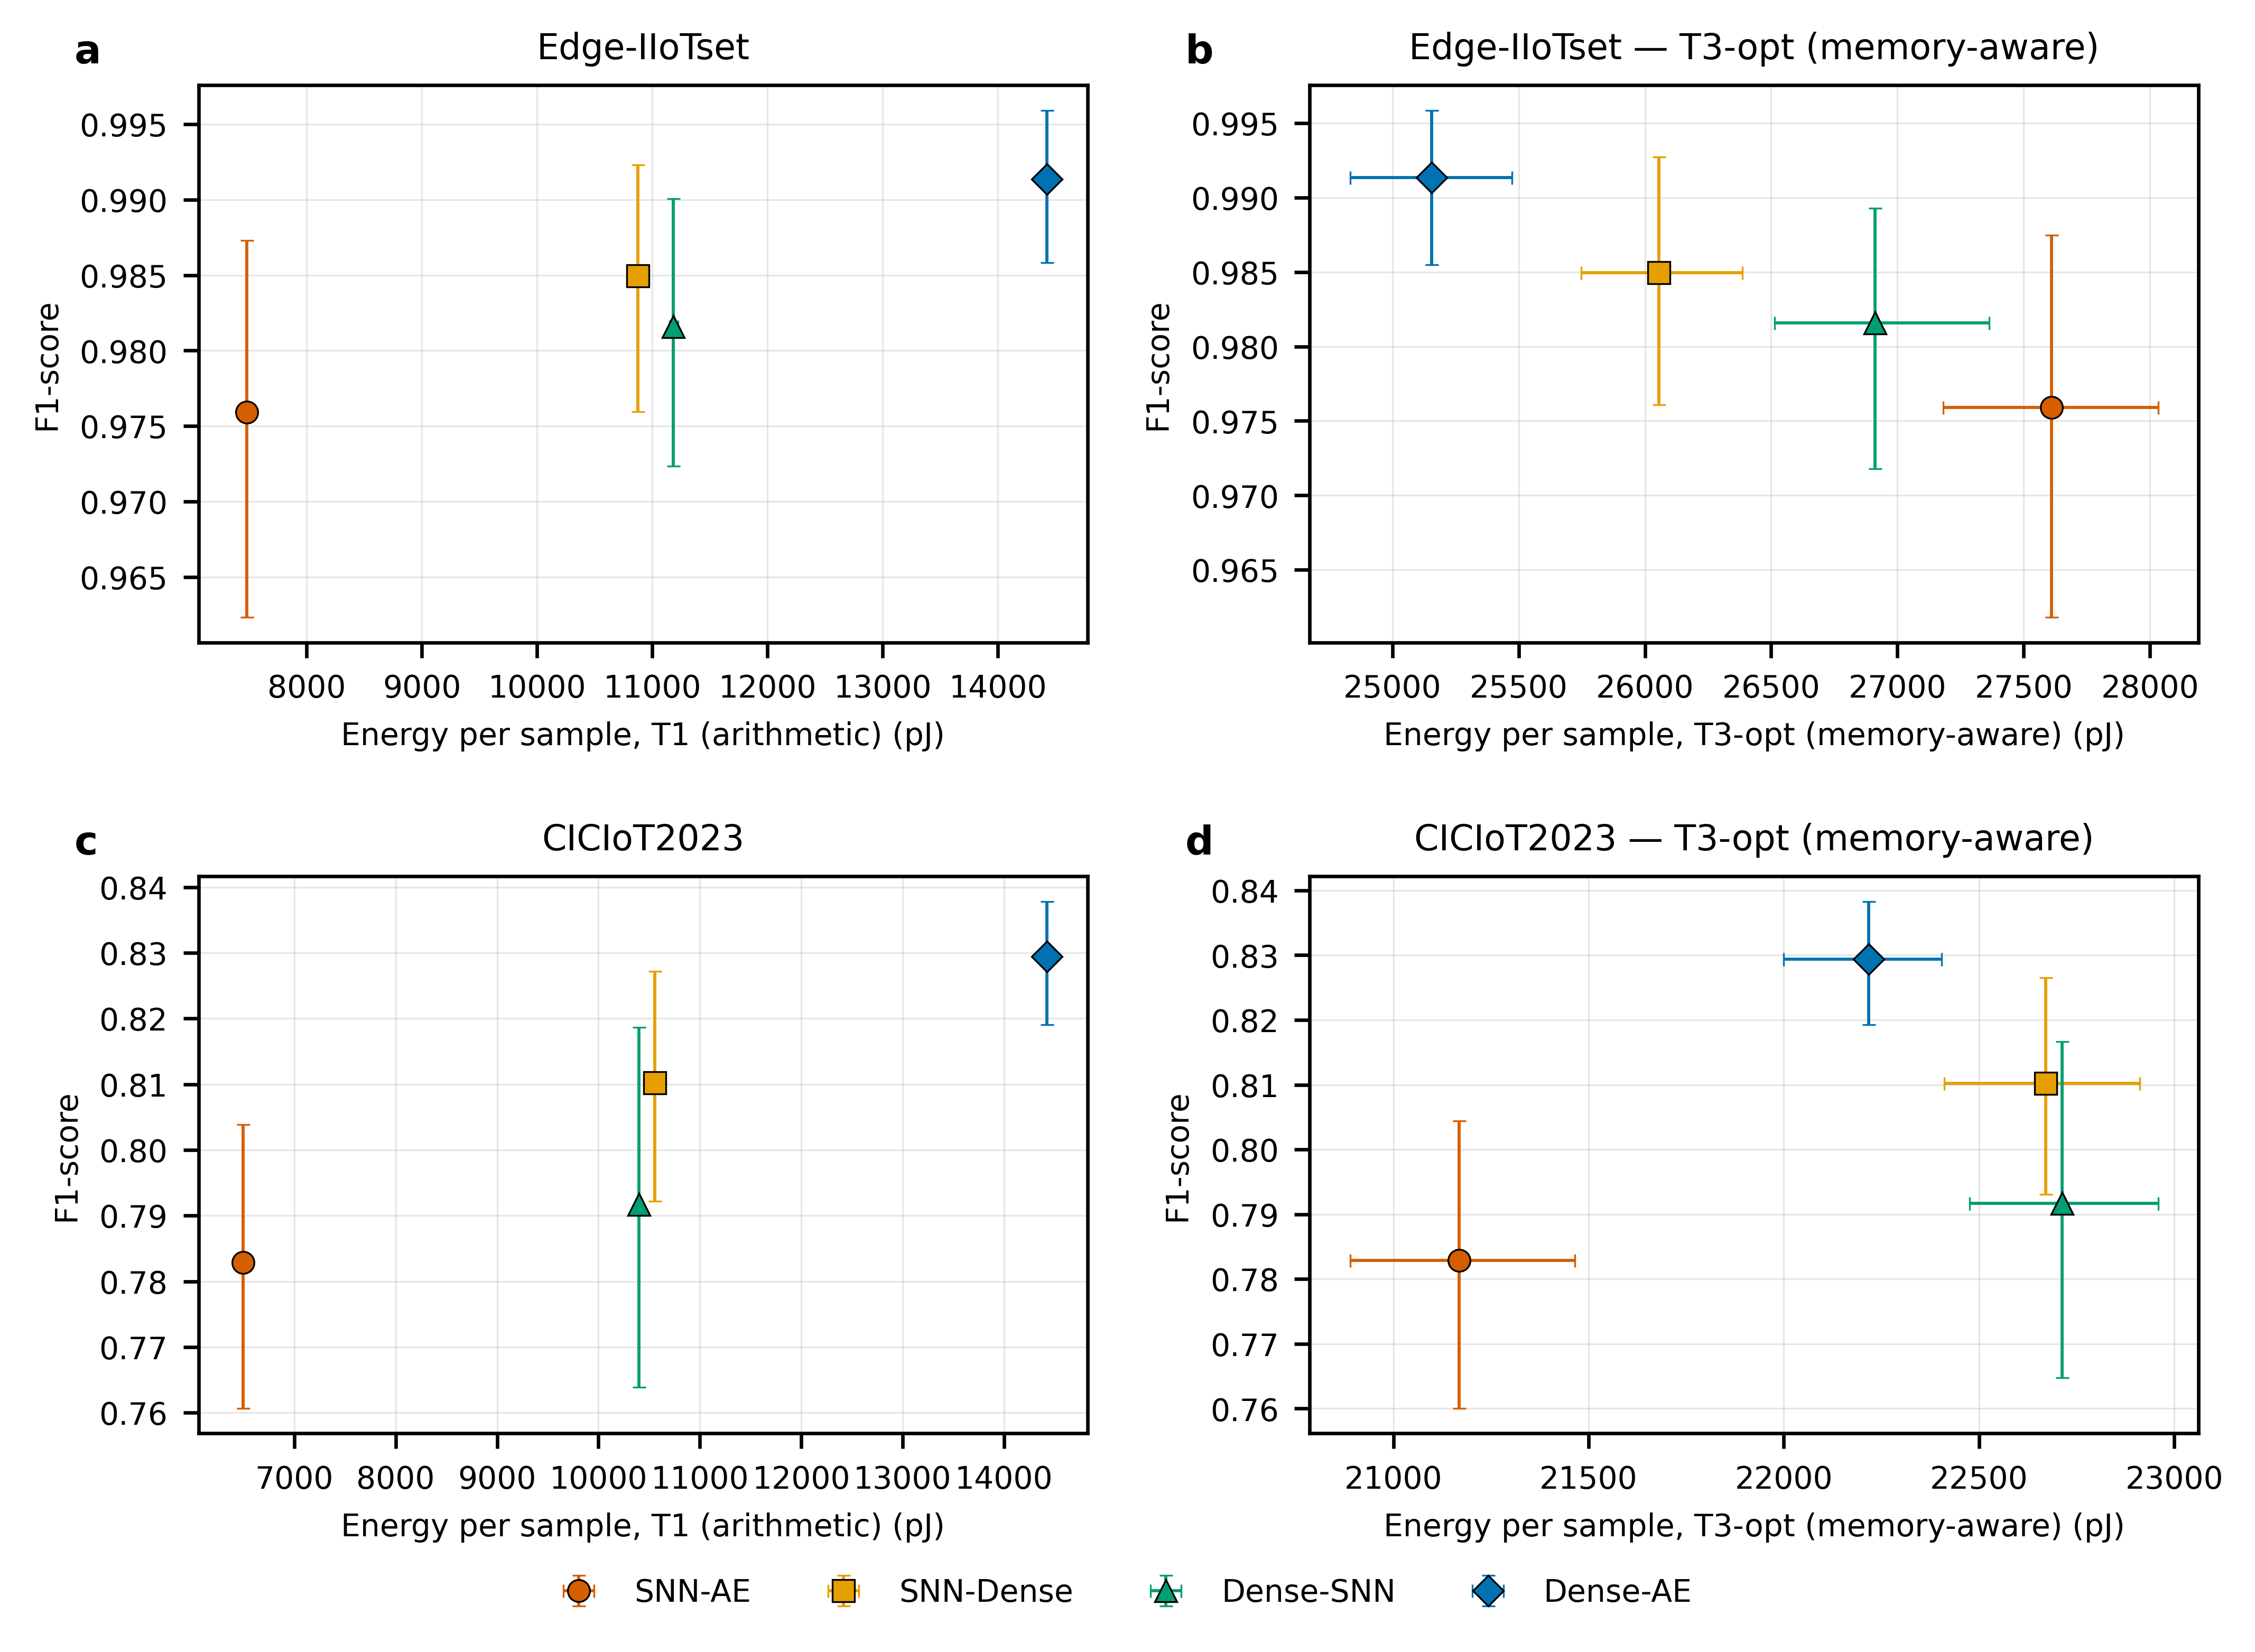

In [20]:
# ======== START: IMPORT ========
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display
# ======== END: IMPORT ========


# ======== START: KONFIGURASI ========
BASE = Path("/home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision")
REP = BASE / "article-reports"
OUT_NAME = "fig5.png"                               # nama = Fig. 5 naskah (trade-off arsitektur)
DPI = 600                                           # UBAH: resolusi PNG
MM = 1 / 25.4
FIG_W, FIG_H = 180, 135                             # UBAH: ukuran gambar (mm)
plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
                     "font.size": 7, "axes.titlesize": 8, "legend.fontsize": 7})

# Tata letak manual
LEFT, RIGHT, TOP, BOTTOM = 0.09, 0.98, 0.94, 0.14   # UBAH: margin figure (fraksi 0–1)
WSPACE, HSPACE = 0.25, 0.42                         # UBAH: jarak antar-kolom / antar-baris
LEG_Y = 0.02                                        # UBAH: posisi vertikal legenda bersama (fraksi figure)

DSN = {"edge_iiotset": "Edge-IIoTset", "ciciot2023": "CICIoT2023"}
VARIANTS = {                                        # UBAH: label, warna (Okabe-Ito), marker
    "SNN_AE":    ("SNN-AE",    "#D55E00", "o"),
    "SNN_Dense": ("SNN-Dense", "#E69F00", "s"),
    "Dense_SNN": ("Dense-SNN", "#009E73", "^"),
    "Dense_AE":  ("Dense-AE",  "#0072B2", "D"),
}
TIERS = {"T1": "T1 (arithmetic)", "T3_opt": "T3-opt (memory-aware)"}   # UBAH: tingkat energi per kolom
EM = 5.0                                            # UBAH: Em (pJ) untuk T3
MS = 5                                              # UBAH: ukuran marker
B_BOOT = 2000                                       # UBAH: resampel bootstrap CI 95%
rng = np.random.default_rng(42)
# ======== END: KONFIGURASI ========


# ======== START: UTILITAS ========
def tokey(s):
    """Label dataset S6 -> kunci internal."""
    return s.replace({v: k for k, v in DSN.items()})

def ci(x):
    """Rata-rata dan CI 95% bootstrap lintas fold."""
    x = np.asarray(x, float)
    b = rng.choice(x, (B_BOOT, len(x))).mean(1)
    return x.mean(), *np.percentile(b, [2.5, 97.5])
# ======== END: UTILITAS ========


# ======== START: DATA DAN VALIDASI ========
E = pd.read_csv(BASE / "07-energy/energy_folds.csv"); E["dataset"] = tokey(E.dataset)
E = E[np.isclose(E.Em, EM) & E.job.isin(VARIANTS)]
cnt = E.groupby(["dataset", "job"]).size()
assert len(cnt) == len(DSN) * len(VARIANTS) and (cnt == 30).all(), cnt
# ======== END: DATA DAN VALIDASI ========


# ======== START: FIGURE DAN TATA LETAK ========
fig, ax = plt.subplots(len(DSN), len(TIERS), figsize=(FIG_W * MM, FIG_H * MM))
fig.subplots_adjust(left=LEFT, right=RIGHT, top=TOP, bottom=BOTTOM, wspace=WSPACE, hspace=HSPACE)
# ======== END: FIGURE DAN TATA LETAK ========


# ======== START: PANEL F1 vs ENERGI (baris = dataset, kolom = tingkat energi) ========
SUMMARY = []
for r, ds in enumerate(DSN):
    for c, (tier, tlab) in enumerate(TIERS.items()):
        a = ax[r, c]
        for job, (lab, col, mk) in VARIANTS.items():
            X = E[(E.dataset == ds) & (E.job == job)]
            ex, fy = ci(X[tier]), ci(X.f1)
            a.errorbar(ex[0], fy[0], xerr=[[ex[0] - ex[1]], [ex[2] - ex[0]]],
                       yerr=[[fy[0] - fy[1]], [fy[2] - fy[0]]], fmt=mk, ms=MS, color=col,
                       mec="black", mew=.4, elinewidth=.7, capsize=1.5, label=lab)
            SUMMARY.append({"dataset": DSN[ds], "tier": tier, "model": lab,
                            "energy_mean": round(ex[0]), "f1_mean": round(fy[0], 4)})
        a.set(xlabel=f"Energy per sample, {tlab} (pJ)", ylabel="F1-score")
        a.set_title(f"{DSN[ds]} — {tlab}" if c else DSN[ds])
        a.grid(alpha=.3, lw=.4)
# ======== END: PANEL F1 vs ENERGI ========


# ======== START: LEGENDA, LABEL PANEL, SIMPAN ========
h, l = ax[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", bbox_to_anchor=(.5, LEG_Y), ncol=len(VARIANTS), frameon=False)
for k, a in enumerate(ax.flat):
    a.text(-0.14, 1.04, "abcd"[k], transform=a.transAxes, fontweight="bold", fontsize=9)
fig.savefig(REP / OUT_NAME, dpi=DPI, bbox_inches="tight"); plt.close(fig)
print(pd.DataFrame(SUMMARY).to_string(index=False))  # angka per titik (cek cepat)
display(Image(filename=str(REP / OUT_NAME), width=900))
# ======== END: LEGENDA, LABEL PANEL, SIMPAN ========

s7b: s7b_summary_20261002_2054.csv
sisa waktu di luar tiga tahap (µs/paket, maks): 0.01
tabel: table_R2.10_rpi_inference.csv, table_R2.11_end_to_end.csv, table_R2.11_parity.csv


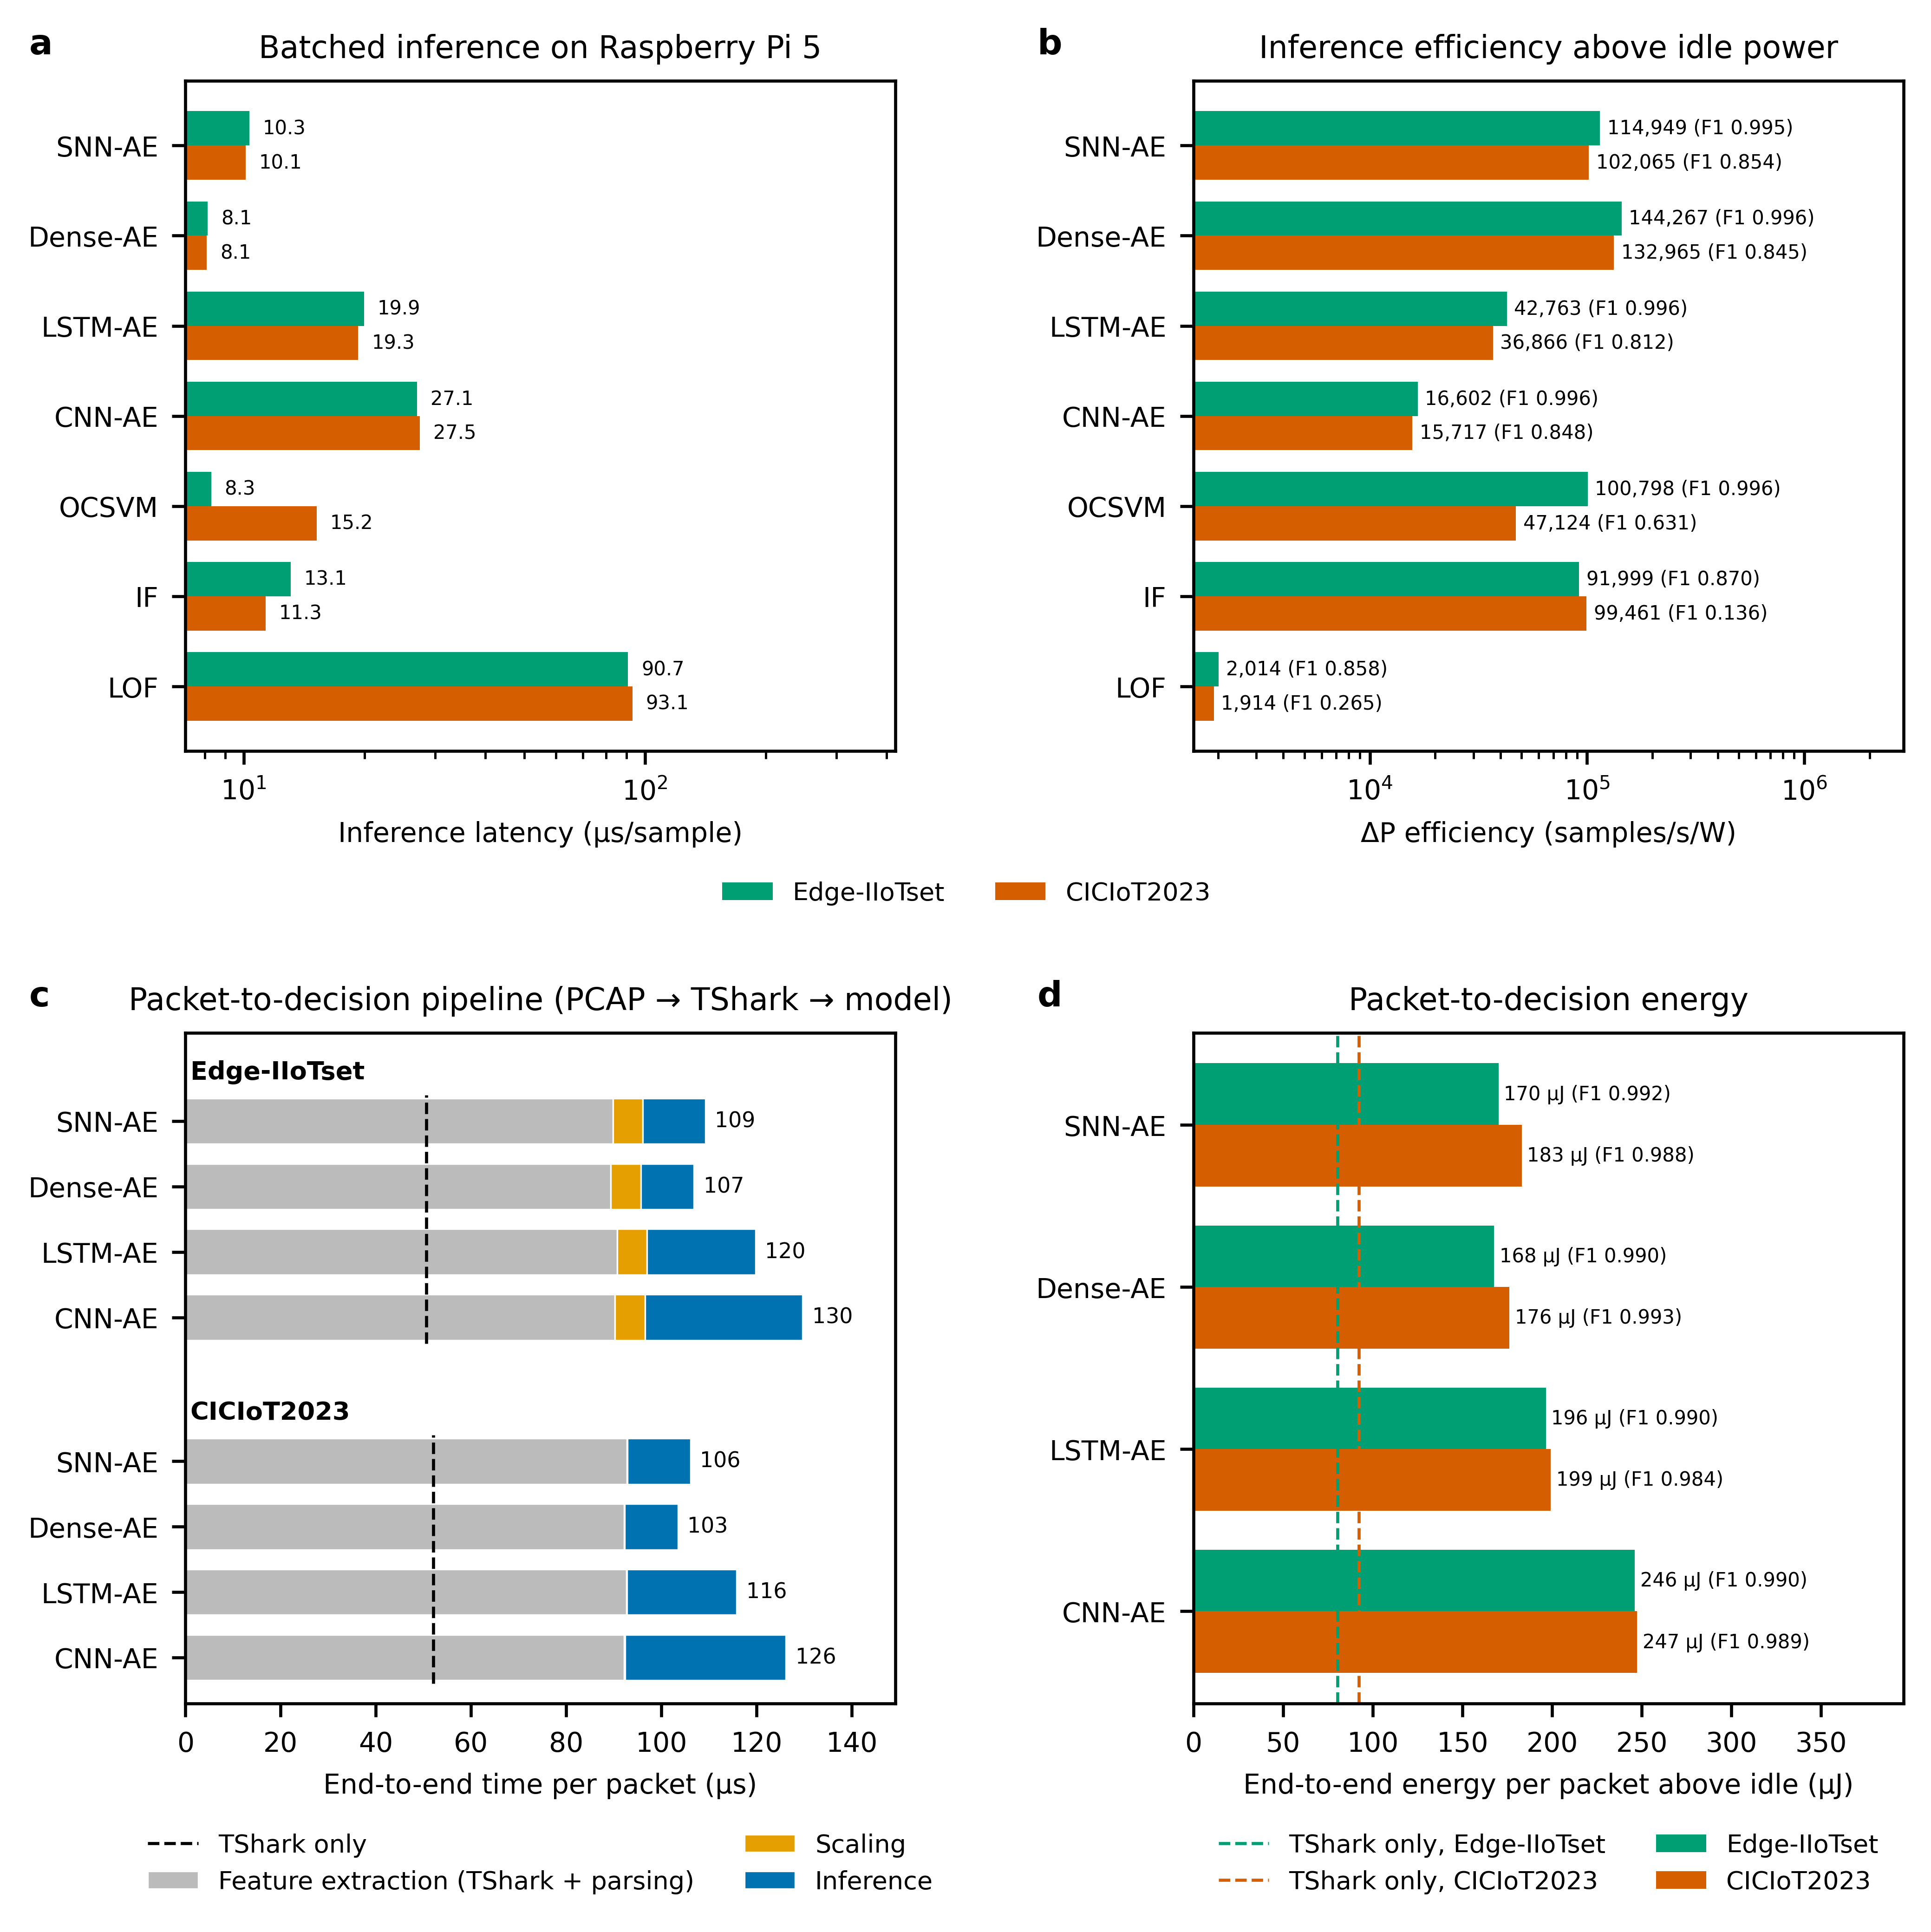

In [24]:
# ======== START: IMPORT ========
import glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display
# ======== END: IMPORT ========


# ======== START: KONFIGURASI ========
BASE = Path("/home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision")
REP = BASE / "article-reports"
OUT_NAME = "fig6.png"                               # nama = Fig. 6 naskah (validasi Raspberry Pi 5)
DPI = 600                                           # UBAH: resolusi PNG
MM = 1 / 25.4
FIG_W, FIG_H = 180, 170                             # UBAH: ukuran gambar (mm)
plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
                     "font.size": 7, "axes.titlesize": 8, "legend.fontsize": 6.5})

# Tata letak manual
LEFT, RIGHT, TOP, BOTTOM = 0.10, 0.97, 0.95, 0.08   # UBAH: margin figure
WSPACE, HSPACE = 0.42, 0.42                         # UBAH: jarak antar-kolom / antar-baris
LEG_Y = -0.16                                       # UBAH: posisi legenda di bawah sumbu x

DSN = {"edge_iiotset": "Edge-IIoTset", "ciciot2023": "CICIoT2023"}
DS_S7A = {"edge": "edge_iiotset", "cici": "ciciot2023"}            # kode dataset di s7a
DCOL = {"edge_iiotset": "#009E73", "ciciot2023": "#D55E00"}       # warna dataset (sama dgn Fig. 4/5)
MODELS_A = ["SNN_AE", "Dense_AE", "LSTM_AE", "CNN_AE", "OCSVM", "IF", "LOF"]  # UBAH: urutan panel a/b
MODELS_C = ["SNN_AE", "Dense_AE", "LSTM_AE", "CNN_AE"]                       # model end-to-end (s7b)
MLAB = {"SNN_AE": "SNN-AE", "Dense_AE": "Dense-AE", "LSTM_AE": "LSTM-AE", "CNN_AE": "CNN-AE",
        "OCSVM": "OCSVM", "IF": "IF", "LOF": "LOF"}
STAGES = {"parse_s": ("Feature extraction (TShark + parsing)", "#BBBBBB"),
          "scale_s": ("Scaling", "#E69F00"),
          "infer_s": ("Inference", "#0072B2")}                    # UBAH: warna tahap
BAR_H = 0.38                                        # UBAH: tinggi batang panel a, b, d
GROUP_GAP = 1.2                                     # UBAH: jarak antar-grup dataset di panel c
LBL = 5                                             # UBAH: ukuran font label nilai
F1_DEC = 3                                          # UBAH: jumlah desimal F1 di label (3 = hindari "1.00" semu)
XPAD_B = 16                                         # UBAH: ruang kanan panel b untuk label nilai + F1
# ======== END: KONFIGURASI ========


# ======== START: DATA DAN VALIDASI ========
A = pd.read_csv(BASE / "08-rpi/s7a/s7a_final_table.csv")
A["dataset"] = A.ds.map(DS_S7A)
assert A.valid.all(), A[~A.valid]
assert set(MODELS_A) <= set(A.model), set(MODELS_A) - set(A.model)

f7b = sorted(glob.glob(str(BASE / "08-rpi/s7b/s7b_summary_*.csv")))[-1]   # ringkasan s7b terbaru
B = pd.read_csv(f7b); print("s7b:", Path(f7b).name)
assert B.valid.all(), B[~B.valid]
TS = B[B.name == "TSHARK_ONLY"].set_index("dataset")
B = B[B.name.isin(MODELS_C)].copy()
for s in STAGES:                                    # waktu per paket per tahap
    B[f"us_{s}"] = B.us_pkt_total * B[s] / B.total_s
B["us_other"] = (B.us_pkt_total - B[[f"us_{s}" for s in STAGES]].sum(1)).clip(lower=0)
print("sisa waktu di luar tiga tahap (µs/paket, maks):", round(B.us_other.max(), 2))
# ======== END: DATA DAN VALIDASI ========


# ======== START: FIGURE DAN TATA LETAK ========
fig, ax = plt.subplots(2, 2, figsize=(FIG_W * MM, FIG_H * MM))
fig.subplots_adjust(left=LEFT, right=RIGHT, top=TOP, bottom=BOTTOM, wspace=WSPACE, hspace=HSPACE)
# ======== END: FIGURE DAN TATA LETAK ========


# ======== START: PANEL (a, b) INFERENSI BATCH (s7a) ========
y = np.arange(len(MODELS_A))[::-1]
for a, col, xlab, with_f1 in [(ax[0, 0], "us", "Inference latency (µs/sample)", False),
                              (ax[0, 1], "sps_w_dlt", "ΔP efficiency (samples/s/W)", True)]:
    for k, ds in enumerate(DSN):
        r = A[A.dataset == ds].set_index("model").loc[MODELS_A]
        yy = y + (0.5 - k) * BAR_H
        a.barh(yy, r[col].values, BAR_H, color=DCOL[ds], label=DSN[ds])
        for yi, vi, f1 in zip(yy, r[col].values, r.f1.values):
            txt = f"{vi:,.0f} (F1 {f1:.{F1_DEC}f})" if with_f1 else f"{vi:.1f}"
            a.text(vi * 1.08, yi, txt, va="center", fontsize=LBL)
    a.set(xscale="log", yticks=y, yticklabels=[MLAB[m] for m in MODELS_A], xlabel=xlab)
    a.set_xlim(right=a.get_xlim()[1] * (XPAD_B if with_f1 else 4))  # ruang untuk label nilai
ax[0, 0].set_title("Batched inference on Raspberry Pi 5")
ax[0, 1].set_title("Inference efficiency above idle power")
ax[0, 0].legend(frameon=False, loc="upper center", bbox_to_anchor=(1.1, LEG_Y), ncol=2)
# ======== END: PANEL (a, b) ========


# ======== START: PANEL (c) WAKTU PER PAKET END-TO-END (s7b) ========
a = ax[1, 0]
n = len(MODELS_C)
yc, heads = [], []
for g, ds in enumerate(DSN):                         # posisi y per grup + posisi judul grup
    top = -g * (n + GROUP_GAP)
    yc += [(ds, m, top - i) for i, m in enumerate(MODELS_C)]
    heads.append((ds, top + 0.75))
for ds, m, yi in yc:
    r = B[(B.dataset == ds) & (B.name == m)].iloc[0]
    left = 0.0
    for s, (lab, colr) in STAGES.items():
        w = r[f"us_{s}"]
        a.barh(yi, w, 0.7, left=left, color=colr, edgecolor="white", lw=.4,
               label=lab if (ds, m) == yc[0][:2] else None)
        left += w
    a.text(left + 2, yi, f"{r.us_pkt_total:.0f}", va="center", fontsize=5.5)
for g, (ds, yh) in enumerate(heads):                 # judul grup + acuan TShark-only
    a.text(1, yh, DSN[ds], ha="left", va="center", fontsize=6.5, fontweight="bold")
    a.vlines(TS.loc[ds, "us_pkt_tshark_only"], yh - n - 0.15, yh - 0.35,
             color="black", ls="--", lw=.8, label="TShark only" if g == 0 else None)
a.set(yticks=[yi for *_, yi in yc], yticklabels=[MLAB[m] for _, m, _ in yc],
      xlabel="End-to-end time per packet (µs)",
      title="Packet-to-decision pipeline (PCAP → TShark → model)")
a.set_ylim(min(yi for *_, yi in yc) - 0.7, heads[0][1] + 0.6)
a.set_xlim(0, B.us_pkt_total.max() * 1.15)
a.legend(frameon=False, loc="upper center", bbox_to_anchor=(.5, LEG_Y), ncol=2)
# ======== END: PANEL (c) ========


# ======== START: PANEL (d) ENERGI PER PAKET END-TO-END (s7b) ========
a = ax[1, 1]
yd = np.arange(len(MODELS_C))[::-1]
for k, ds in enumerate(DSN):
    r = B[B.dataset == ds].set_index("name").loc[MODELS_C]
    yy = yd + (0.5 - k) * BAR_H
    a.barh(yy, r.mJ_pkt_delta * 1000, BAR_H, color=DCOL[ds], label=DSN[ds])   # mJ -> µJ
    for yi, e, f1 in zip(yy, r.mJ_pkt_delta * 1000, r.f1):
        a.text(e + 3, yi, f"{e:.0f} µJ (F1 {f1:.{F1_DEC}f})", va="center", fontsize=LBL)
    a.axvline(TS.loc[ds, "mJ_pkt_delta"] * 1000, color=DCOL[ds], ls="--", lw=.8,
              label=f"TShark only, {DSN[ds]}")
a.set(yticks=yd, yticklabels=[MLAB[m] for m in MODELS_C],
      xlabel="End-to-end energy per packet above idle (µJ)",
      title="Packet-to-decision energy")
a.set_xlim(0, B.mJ_pkt_delta.max() * 1000 * 1.6)
a.legend(frameon=False, loc="upper center", bbox_to_anchor=(.5, LEG_Y), ncol=2)
# ======== END: PANEL (d) ========


# ======== START: LABEL PANEL, SIMPAN, TABEL ========
for k, a in enumerate(ax.flat):
    a.text(-0.22, 1.04, "abcd"[k], transform=a.transAxes, fontweight="bold", fontsize=9)
fig.savefig(REP / OUT_NAME, dpi=DPI, bbox_inches="tight"); plt.close(fig)

A.drop(columns="ds").to_csv(REP / "table_R2.10_rpi_inference.csv", index=False)
pd.read_csv(f7b).to_csv(REP / "table_R2.11_end_to_end.csv", index=False)
pc = pd.read_csv(BASE / "08-rpi/s7b/parity_check.csv"); pm = pd.read_csv(BASE / "08-rpi/s7b/parity_models.csv")
pd.concat([pc.assign(check="feature"), pm.assign(check="model")]).to_csv(
    REP / "table_R2.11_parity.csv", index=False)
print("tabel: table_R2.10_rpi_inference.csv, table_R2.11_end_to_end.csv, table_R2.11_parity.csv")
display(Image(filename=str(REP / OUT_NAME), width=900))
# ======== END: LABEL PANEL, SIMPAN, TABEL ========

In [25]:
# ======== START: KONVERSI CSV KE UTF-8 BOM (agar terbaca benar di Excel/Word) ========
from pathlib import Path
REP = Path("/home/jupyteruser/nix-ext-backup/0-eksperimen-final/0-snn-ae-revision/article-reports")
for f in sorted(REP.glob("*.csv")):
    raw = f.read_bytes()
    if raw.startswith(b"\xef\xbb\xbf"):          # sudah ber-BOM, lewati
        continue
    f.write_text(raw.decode("utf-8"), encoding="utf-8-sig")
    print("dikonversi:", f.name)
# ======== END: KONVERSI CSV KE UTF-8 BOM ========

dikonversi: table2.csv
dikonversi: table3.csv
dikonversi: table4.csv
dikonversi: tableS1_statistics.csv
dikonversi: tableS5_features.csv
dikonversi: tableS6_timestep_ablation.csv
dikonversi: table_R1.1_threshold_grid.csv
dikonversi: table_R1.2_config_full.csv
dikonversi: table_R1.3_baseline_tuning.csv
dikonversi: table_R1.6_detection_ci95.csv
dikonversi: table_R1.6_fold_variability.csv
dikonversi: table_R2.10_rpi_inference.csv
dikonversi: table_R2.11_end_to_end.csv
dikonversi: table_R2.11_parity.csv
dikonversi: table_R2.5_leakage_report.csv
dikonversi: table_R2.5_split_report.csv
dikonversi: table_R2.8_subtype_recall.csv
dikonversi: table_R3.10_latent_subtype_probe.csv
dikonversi: table_R3.10_latent_summary.csv
dikonversi: table_R3.12_energy_components_Em5.csv
dikonversi: table_R3.2b_break_even.csv
dikonversi: table_R3.2b_energy_summary_Em5.csv
dikonversi: table_R3.2b_energy_tests.csv
dikonversi: table_R3.9_ablation_bn_architecture.csv
